# Module 1 demo (20 min) — Multi-Agent Architecture & Communication Patterns
### *AnyCompany Bank: from one overloaded agent to a team of specialists*

**Deck:** M01 · kernel **MLADAS (Python 3.12)** · **your AWS account**, `us-east-1` · **Amazon Nova** models only.

> **Run the setup cells about 5 minutes before you start**, down to *Demo starts here*: the partner agent and the
> AgentCore Memory need that head start.

**The story.** AnyCompany Bank (fictional) splits one overloaded customer-service agent into a team: specialists
behind an orchestrator, a partner credit bureau reached over A2A, and a loan-decision Graph. **Sofia Martinez**
(`CUST-1001`) is remembered across days, **Aisha Patel** (`CUST-1003`) applies for a loan, and the **Octank Credit
Bureau** is another company's agent.

| § | Highlight | Slides |
|---|---|---|
| §2 | an orchestrator with **no** back-end API and least-privilege specialists, **measured** against one agent | 7, 10, 13 |
| §8 | Sofia's Day 1: one **AgentCore Memory** for the whole team | 31–33, 39 |
| §3 | the partner's agent over **A2A on AgentCore Runtime** | 9, 18, 25 |
| §5 | the **Graph** loan decision: code nodes, a remote A2A node, a review loop | 16, 21 |
| §8 | Days 3 and 7: a specialist that never met Sofia remembers her | 26–34, 39 |
| §9–10 | one discussion, what it cost (Nova and Memory), cleanup verified by id | 38 |

<details><summary>Not in this demo (the course's 60-minute notebook covers it)</summary>

§1 why one agent isn't enough · §2.3 graceful degradation and a circuit breaker · §3.7 the partner as a tool of the
bank's agent · §4 Workflow · §6 Swarm · §7 shared state (`invocation_state`) · the knowledge check. That notebook
is not part of this repository.
</details>

> **Cost:** well under $1 per run. §10 deletes every AWS resource of this `RUN_ID` and verifies each by id.

> **Student copy, executed.** The recorded outputs of one verified run of `M01_multi_agent_demo20.ipynb` (September 2026, us-east-1), so you can read the results without an AWS account. Account ids and IAM identities are masked in the outputs. Not an official AWS training product; AnyCompany Bank, the Octank Credit Bureau and all their data are fictional. To run the demo, open `M01_multi_agent_demo20.ipynb` and read this module's `README.md`. Code: MIT-0 (`LICENSE`) · text: CC BY-SA 4.0 (`LICENSE-CONTENT`).

## §0 — Setup and early start (run it ~5 minutes before you read on)
The collapsed cells check the environment, create the `RUN_ID` that names every AWS resource of this run, and load
the Nova-only agent factory with its cost **ledger** (a hook on every agent). Two slow resources start **in the
background**: the partner agent on **AgentCore Runtime** (§3, §5) and one **AgentCore Memory** with four long-term
strategies (§8). If the runtime isn't ready or healthy, `get_bureau_agent()` serves the same partner code on
`localhost` and says so: slide 12's *redundancy*.

<details><summary>Fallback flags and re-runs</summary>

- `M01_DEPLOY_RUNTIME=0`: §3 and §5 use the localhost partner, and a banner says why.
- `M01_CREATE_MEMORY=0`: §8 creates the memory on demand and waits for it (about 2.5 min).
- Every setup cell is safe to re-run. If the kernel dies: `python teardown_m01.py --last` (or `--run-id <RUN_ID>`).
</details>

In [1]:
# environment check, RUN_ID, Nova-only agent factory and cost ledger
import os, sys, json, time, textwrap, uuid, warnings, logging
from datetime import datetime, timezone
from pathlib import Path

# Local Mac: point Python at certifi's CA bundle (python.org builds ship without trust roots)
try:
    import certifi
    os.environ.setdefault("SSL_CERT_FILE", certifi.where())
    os.environ.setdefault("REQUESTS_CA_BUNDLE", certifi.where())
except ImportError:
    pass

NOTEBOOK_DIR = Path.cwd()
DEMOS_ROOT = NOTEBOOK_DIR.parent                     # the repo root: shared helpers + bank data live here
if str(DEMOS_ROOT) not in sys.path:
    sys.path.insert(0, str(DEMOS_ROOT))

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*A2A.*stream.*")         # strands legacy-stream notice
logging.getLogger("strands").setLevel(logging.ERROR)

import pandas as pd
import matplotlib.pyplot as plt
import mladas_common as mc
import mladas_viz as viz
import bank_data as bank
from mladas_common import LEDGER, make_agent, nova, text_of, tool_calls, parse_json

viz.apply_style()

REQUIRED = {"strands-agents": "1.57", "bedrock-agentcore": "1.23", "a2a-sdk": "0.3"}
versions = mc.stack_versions()
for pkg, want in REQUIRED.items():
    assert versions[pkg].startswith(want), f"{pkg} {versions[pkg]} found, {want}.x expected — run ../setup_env.sh"

ident = mc.whoami()
SESSION = mc.get_session()
ACCOUNT, REGION = ident["account"], ident["region"]
# Re-running this cell keeps the same RUN_ID, so resources already created stay reachable for cleanup.
RUN_ID = globals().get("RUN_ID") or os.getenv("M01_RUN_ID") or \
    f"{datetime.now(timezone.utc):%Y%m%d-%H%M%S}-{uuid.uuid4().hex[:4]}"
with open(NOTEBOOK_DIR / ".m01_run_ids", "a") as f:     # lets `teardown_m01.py --last` find this run later
    f.write(RUN_ID + "\n")

print(f"AWS identity : {mc.mask_account(ident['arn'], ACCOUNT)}  (profile={ident['profile']}, region={REGION})")
print(f"RUN_ID       : {RUN_ID}")
print("SDK stack    :", "  ".join(f"{k}={v}" for k, v in versions.items()))

AWS identity : arn:aws:iam::************:user/<you>  (profile=<your profile>, region=us-east-1)
RUN_ID       : 20260928-091109-55e9
SDK stack    : strands-agents=1.57.1  strands-agents-tools=0.8.9  bedrock-agentcore=1.23.1  a2a-sdk=0.3.26  boto3=1.43.103


In [2]:
from agentcore_deploy import RuntimeDeployment

DEPLOY_RUNTIME = os.getenv("M01_DEPLOY_RUNTIME", "1") == "1"      # set to 0 to use only the local fallback
BUREAU_SOURCE = NOTEBOOK_DIR / "partner_credit_bureau"

bureau_job = globals().get("bureau_job")
if bureau_job is not None and bureau_job.status != "FAILED":
    print(f"Already started: {bureau_job.name} ({bureau_job.status}) — not deploying a second copy.")
elif DEPLOY_RUNTIME:
    bureau_job = RuntimeDeployment(
        name="mladas_m01_bureau", source_dir=BUREAU_SOURCE, run_id=RUN_ID, session=SESSION,
        protocol="A2A", model_ids=(mc.MODELS["nova-2-lite"],),
        environment={"BUREAU_MODEL_ID": mc.MODELS["nova-2-lite"]},
        description="MLADAS M01 - partner credit bureau agent (A2A)", tags={"module": "M01"},
    ).start()
    print(f"Deploying {bureau_job.name} in the background ... (check with bureau_job.progress())")
else:
    print("M01_DEPLOY_RUNTIME=0 -> §3/§5 will use a local A2A server instead of AgentCore Runtime.")

Deploying mladas_m01_bureau_2026092809110955e9 in the background ... (check with bureau_job.progress())


In [3]:
# partner agent with a localhost backup (redundancy) + CreateMemory in the background
import importlib.util
import httpx
from bedrock_agentcore.runtime import build_a2a_app
from strands.agent.a2a_agent import A2AAgent

# Load the partner's module by path under an explicit name (it is another company's code, not a package of ours)
_spec = importlib.util.spec_from_file_location("octank_bureau_agent", BUREAU_SOURCE / "agent.py")
bureau_code = importlib.util.module_from_spec(_spec)
sys.modules["octank_bureau_agent"] = bureau_code
_spec.loader.exec_module(bureau_code)

_local_bureau = globals().get("_local_bureau") or {"server": None}
_bureau_health: dict[str, bool] = globals().get("_bureau_health") or {}
LOCAL_BUREAU_PORT = _local_bureau["server"].port if _local_bureau["server"] else mc.free_port(9141)


def start_local_bureau() -> str:
    """Serve the bureau agent on localhost (A2A): the redundant backup instance."""
    if _local_bureau["server"] is None:
        bureau_code.BOTO_SESSION = SESSION         # local run -> the notebook's AWS session
        url = f"http://127.0.0.1:{LOCAL_BUREAU_PORT}/"
        app = build_a2a_app(bureau_code.executor(), bureau_code.agent_card(url))
        _local_bureau["server"] = mc.A2AServerThread(app, port=LOCAL_BUREAU_PORT).start()
    return _local_bureau["server"].url


def runtime_healthy() -> bool:
    """READY is not enough: probe the Agent Card once (signed GET, 30 s timeout) and cache the answer.
    The probe's session id is kept, so the next call reuses that already-warm microVM."""
    if "ok" not in _bureau_health:
        _bureau_health["session_id"] = mc.runtime_session_id("anycompany")
        try:
            r = httpx.get(mc.runtime_a2a_url(bureau_job.runtime_arn) + ".well-known/agent-card.json",
                          auth=mc.SigV4HttpxAuth(), timeout=30,
                          headers={"X-Amzn-Bedrock-AgentCore-Runtime-Session-Id": _bureau_health["session_id"]})
            _bureau_health["ok"] = r.status_code == 200 and "name" in r.json()
        except Exception:                          # network, 4xx/5xx, bad JSON: all mean "use the backup"
            _bureau_health["ok"] = False
        if not _bureau_health["ok"]:
            print("AgentCore Runtime is READY but not answering -> using the local backup instance")
    return _bureau_health["ok"]


def get_bureau_agent(wait_s: float = 0, name: str = "credit_bureau", session_id: str | None = None,
                     force_local: bool = False):
    """Return (A2AAgent, where): the Runtime-hosted agent if READY and healthy, else the local backup.
    By default it reuses the health probe's warm session; pass session_id for a fresh one, force_local to skip Runtime."""
    if not force_local and bureau_job is not None and not bureau_job.ready and wait_s:
        print(f"Waiting up to {wait_s:.0f} s for the partner runtime ({bureau_job.status}) ...")
        bureau_job.wait(timeout=wait_s, verbose=False)
    if not force_local and bureau_job is not None and bureau_job.ready and runtime_healthy():
        return (mc.runtime_a2a_agent(bureau_job.runtime_arn, name=name, timeout=90,
                                     session_id=session_id or _bureau_health.get("session_id")),
                "AgentCore Runtime")
    return A2AAgent(endpoint=start_local_bureau(), name=name, timeout=90), "local backup (localhost)"

In [4]:
# partner agent with a localhost backup (redundancy) + CreateMemory in the background
from botocore.exceptions import ClientError

CREATE_MEMORY = os.getenv("M01_CREATE_MEMORY", "1") == "1"      # set to 0 to skip (§8 can create it on demand)
MEMORY_NAME = "MLADAS_M01_" + RUN_ID.replace("-", "_")         # [a-zA-Z][a-zA-Z0-9_]{0,47}: no hyphens

CUSTOMER_NS_TEMPLATES = {
    "preferences": "/customers/{customerid}/preferences/",
    "facts":       "/customers/{customerid}/facts/",
    "sessions":    "/customers/{customerid}/sessions/{sessionId}/",
}
AGENT_NS_TEMPLATES = {
    "episodes":    "/agents/{actorId}/episodes/{sessionId}/",
    "reflections": "/agents/{actorId}/",                        # must be a prefix of the episode template
}
MEMORY_STRATEGIES = [
    {"userPreferenceMemoryStrategy": {"name": "CustomerPreferences",
                                      "namespaceTemplates": [CUSTOMER_NS_TEMPLATES["preferences"]]}},
    {"semanticMemoryStrategy": {"name": "CustomerFacts",
                                "namespaceTemplates": [CUSTOMER_NS_TEMPLATES["facts"]]}},
    {"summaryMemoryStrategy": {"name": "SessionSummaries",
                               "namespaceTemplates": [CUSTOMER_NS_TEMPLATES["sessions"]]}},
    {"episodicMemoryStrategy": {"name": "AgentEpisodes",
                                "namespaceTemplates": [AGENT_NS_TEMPLATES["episodes"]],
                                "reflectionConfiguration": {"namespaceTemplates": [AGENT_NS_TEMPLATES["reflections"]]}}},
]
memory_control = SESSION.client("bedrock-agentcore-control")
_memory_created_at: dict[str, float] = globals().get("_memory_created_at") or {}


def create_shared_memory() -> str:
    """CreateMemory returns at once (status CREATING); poll with wait_memory_active()."""
    memory = memory_control.create_memory(
        name=MEMORY_NAME,
        description="MLADAS M01 - one memory shared by the AnyCompany Bank agent team",
        eventExpiryDuration=7,                                   # days of raw events (3..365)
        memoryStrategies=MEMORY_STRATEGIES,
        namespaceKeys=[{"key": "customerid", "validation": {"regexPattern": "^cust-[0-9]{4}$"}}],
        tags={"module": "M01", "run_id": RUN_ID},
        clientToken=str(uuid.uuid4()),
    )["memory"]
    _memory_created_at[memory["id"]] = time.time()
    return memory["id"]


def wait_memory_active(timeout: float = 300, poll: float = 10) -> dict:
    """Block until MEMORY_ID is ACTIVE (prints progress); returns the GetMemory description."""
    t0 = time.time()
    while True:
        memory = memory_control.get_memory(memoryId=MEMORY_ID)["memory"]
        age = time.time() - _memory_created_at.get(MEMORY_ID, t0)
        if memory["status"] == "ACTIVE":
            print(f"Memory {MEMORY_ID} is ACTIVE (checked {age:.0f}s after CreateMemory).")
            return memory
        if memory["status"] == "FAILED":
            raise RuntimeError(f"Memory creation failed: {memory.get('failureReason')}")
        if time.time() - t0 > timeout:
            raise TimeoutError(f"Memory still {memory['status']} after {timeout:.0f}s — re-run this cell.")
        print(f"  {age:4.0f}s  {memory['status']} ...")
        time.sleep(poll)


MEMORY_ID = globals().get("MEMORY_ID")                          # re-running this cell must not create a 2nd memory
if MEMORY_ID:
    print(f"Already created: {MEMORY_ID} — not creating a second memory.")
elif CREATE_MEMORY:
    try:
        MEMORY_ID = create_shared_memory()
        print(f"Creating AgentCore Memory {MEMORY_NAME} -> {MEMORY_ID} (CREATING, ready in ~2-4 min; used in §8)")
    except ClientError as e:                                     # never stop "Run All" here: §8 retries on demand
        print(f"CreateMemory failed ({e.response['Error']['Code']}: {e.response['Error']['Message'][:120]}). "
              "§8 will try again on demand.")
else:
    print("M01_CREATE_MEMORY=0 -> no AgentCore Memory yet (MEMORY_ID=None). §8 creates one on demand.")

Creating AgentCore Memory MLADAS_M01_20260928_091109_55e9 -> MLADAS_M01_20260928_091109_55e9-dwRiFG71WK (CREATING, ready in ~2-4 min; used in §8)


---
## ▶ Demo starts here
**Ready check:** the partner runtime must be **READY** and the memory **ACTIVE**. With the 5-minute head start this
returns at once; otherwise it waits on one status line (at most 4 min). If it gives up, carry on: §3 falls back to
the localhost partner and §8 waits for the memory.

In [5]:
from IPython.display import Pretty

d20_status, d20_t0 = display(Pretty("checking ..."), display_id=True), time.time()
while True:
    d20_runtime = bureau_job.status if bureau_job is not None else "off (localhost backup)"
    try:
        d20_memory = memory_control.get_memory(memoryId=MEMORY_ID)["memory"]["status"] if MEMORY_ID else "none (§8)"
    except ClientError as d20_err:
        d20_memory = f"unknown ({d20_err.response['Error']['Code']})"
    d20_status.update(Pretty(f"{time.time() - d20_t0:4.0f}s  RUN_ID {RUN_ID} · partner runtime: {d20_runtime} · "
                             f"AgentCore Memory: {d20_memory}"))
    d20_runtime_done = bureau_job is None or bureau_job.status in ("READY", "FAILED")
    if (d20_runtime_done and d20_memory != "CREATING") or time.time() - d20_t0 > 240:
        break
    time.sleep(5)

 152s  RUN_ID 20260928-091109-55e9 · partner runtime: READY · AgentCore Memory: ACTIVE

## §2 — Agent as tool: an orchestrator with least-privilege specialists
*Deck slides 7, 10, 13–15, 17.* Customer service becomes an **orchestrator that owns no back-end API**, plus three
specialists with only their own domain's APIs. The deck's default (slide 15): **begin with agents as tools**. The
split buys least privilege and costs tokens, so we measure it against one agent, as slide 13 asks.

### 2.1 Three specialists, each with only the APIs it needs (slides 7, 10)

A specialist is three things: a **focused system prompt**, a **small tool set**, and a **model**. The bank's
back-end functions in `bank_data.py` (core banking, card processor, loan origination, case management) become
Strands tools with `tool(fn)`: the function name, docstring and type hints turn into the tool spec.

**A prompt recipe that works for Nova** (the prompts in this module follow it): a role · the tool work first ·
an explicit output format · explicit negatives (`NO_FLUFF` below). Nova 2 Lite ignores soft limits such as
"be brief". In our testing a soft limit produced 870–980 output tokens, and a `MaxTokensReachedException` when
`max_tokens` was low, while an explicit format plus negatives produced about 20.

In [6]:
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
import re
import threading

from strands import tool
from strands.hooks import BeforeToolCallEvent

LEDGER.clear_section("§2")                     # re-running this section must not double count in §9

# Every back-end API of the bank as a Strands tool (name, docstring and type hints -> tool spec)
API = {fn.__name__: tool(fn) for fn in bank.BACKEND_APIS}
MONOLITH_COLOR = viz.ROLE_COLORS["monolith"]   # the single-agent baseline, wherever it appears in this section

NO_FLUFF = ("No headings, no lists, no markdown, no greetings, no offers of further help. "
            "Never promise emails, calls, texts or timelines that no tool returned.")

SPECIALISTS = {
    "accounts_specialist": {
        "description": ("Deposit accounts: checking and savings balances, customer profile and contact preferences. "
                        "Send the request together with the customer id."),
        "tools": ["get_customer_profile", "get_account_balances"],
        "prompt": ("You are the accounts specialist of AnyCompany Bank: deposit balances and customer profiles.\n"
                   "Use your tools for every fact and never guess a number; quote amounts exactly as the tools return them.\n"
                   "Output format: 1-3 plain sentences that answer only the accounts part of the request.\n"
                   f"{NO_FLUFF} Do not discuss cards or loans; other specialists handle them."),
    },
    "cards_specialist": {
        "description": ("Cards: card transactions, duplicate charges, billing disputes, unrecognized or fraudulent charges, "
                        "blocking a card, security events. Send the request with the customer id and card ending."),
        "tools": ["list_card_transactions", "find_duplicate_charges", "get_dispute_policy", "open_case",
                  "block_card", "get_security_events"],
        "prompt": ("You are the cards specialist of AnyCompany Bank: card transactions, disputes and fraud.\n"
                   "Use your tools for every fact. Confirm a suspected double charge with find_duplicate_charges and, if the "
                   "customer asks for a dispute, open a billing_dispute case. If the customer did not make some charges, "
                   "block the card and open a fraud case.\n"
                   "Output format: 1-3 plain sentences with the facts found (amounts, dates, case id) and the action taken.\n"
                   f"{NO_FLUFF} Do not discuss accounts or loans; other specialists handle them."),
    },
    "lending_specialist": {
        "description": ("Lending: loan products, APR ranges and terms, monthly payment calculations, loan application "
                        "status, credit-score and debt-to-income policy. Send the request with amounts, terms and "
                        "application ids."),
        "tools": ["get_loan_products", "get_lending_policy", "get_application", "monthly_payment"],
        "prompt": ("You are the lending specialist of AnyCompany Bank: loan products, payments, applications and policy.\n"
                   "Use your tools for every fact. Always compute payments with monthly_payment; never do loan arithmetic "
                   "yourself. 'Lowest advertised rate' means the lowest APR in the product's apr_range.\n"
                   "Output format: 1-3 plain sentences with the numbers (APR, term in months, payment, status).\n"
                   f"{NO_FLUFF} Do not discuss accounts or cards; other specialists handle them."),
    },
}

TRACE: list[dict] = []        # routing trace: which agent called which tool, with what input


def trace_tool_call(event: BeforeToolCallEvent) -> None:
    """Hook (a typed callback): record every tool call an agent is about to make."""
    TRACE.append({"caller": event.agent.name, "tool": event.tool_use["name"], "input": event.tool_use["input"],
                  "id": event.tool_use["toolUseId"]})


def build_specialist(name: str, *, hooks: tuple = (trace_tool_call,)):
    """Specialist = focused prompt + ONLY its domain's APIs + Nova 2 Lite (make_agent's default model)."""
    spec = SPECIALISTS[name]
    return make_agent(name, spec["prompt"], description=spec["description"],
                      tools=[API[t] for t in spec["tools"]], hooks=list(hooks))


print(f"{len(API)} back-end APIs wrapped as tools; specialists: {', '.join(SPECIALISTS)}")

13 back-end APIs wrapped as tools; specialists: accounts_specialist, cards_specialist, lending_specialist


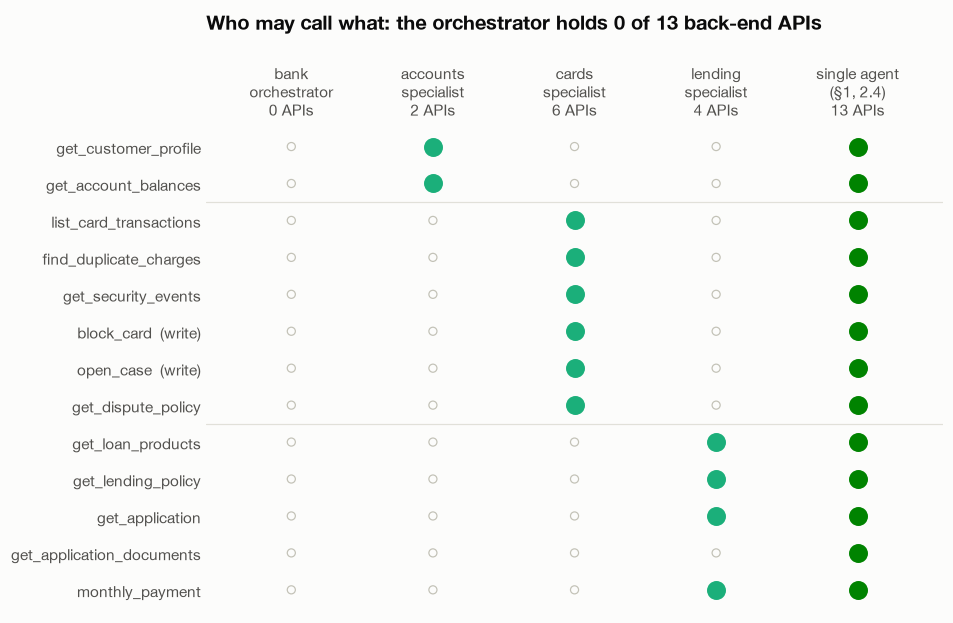

In [7]:
WRITE_APIS = {"open_case", "block_card"}   # side effects in the bank's systems of record
GRANT_COLUMNS = {"bank\norchestrator": ([], viz.ROLE_COLORS["orchestrator"]),
                 **{n.replace("_", "\n"): (s["tools"], viz.ROLE_COLORS["specialist"]) for n, s in SPECIALISTS.items()},
                 "single agent\n(§1, 2.4)": (list(API), MONOLITH_COLOR)}
api_rows = list(API)

fig, ax = plt.subplots(figsize=(8.8, 5.8))
for grant_x, (granted, dot_color) in enumerate(GRANT_COLUMNS.values()):
    for grant_y, api_name in enumerate(api_rows):
        if api_name in granted:
            ax.scatter(grant_x, grant_y, s=130, color=dot_color, zorder=3)
        else:
            ax.scatter(grant_x, grant_y, s=28, facecolors="none", edgecolors=viz.AXIS, linewidths=0.8, zorder=2)
ax.set_xticks(range(len(GRANT_COLUMNS)), [f"{label}\n{len(allowed)} APIs" for label, (allowed, _) in GRANT_COLUMNS.items()])
ax.set_yticks(range(len(api_rows)), [f"{a}  (write)" if a in WRITE_APIS else a for a in api_rows])
ax.xaxis.tick_top()
ax.tick_params(length=0)
ax.set_xlim(-0.6, len(GRANT_COLUMNS) - 0.4)
ax.set_ylim(len(api_rows) - 0.4, -0.6)
for boundary in (1.5, 7.5):                         # accounts | cards | lending
    ax.axhline(boundary, color=viz.GRID, linewidth=0.8)
ax.grid(False)
for spine_side in ("left", "bottom", "top", "right"):
    ax.spines[spine_side].set_visible(False)
ax.set_title(f"Who may call what: the orchestrator holds 0 of {len(API)} back-end APIs", pad=62)
plt.tight_layout()
plt.show()

### 2.2 The orchestrator: specialist agents *are* its tools (slides 15, 17)
> **2026 update:** since Strands v1.34 an `Agent` passed in `tools=[...]` is wrapped automatically. Its `name` and
> `description` become the tool's name and description: those two strings *are* the routing logic.

`as_tool()` forwards only the input string, so a `BeforeToolCallEvent` hook prepends the signed-in customer header
from `invocation_state` to every specialist input: code, so it happens every time (slide 23).

In [8]:
ORCHESTRATOR_PROMPT = (
    "You are the front desk of AnyCompany Bank customer service. You have no access to bank systems: you delegate to "
    "specialist tools and combine their answers.\n"
    "1. Split the customer's message into its requests and send each request to the specialist whose description fits.\n"
    "2. Call each specialist at most once; put all of its requests into that one input. If a specialist returns status "
    "'unavailable', do not call it again: tell the customer that part is temporarily unavailable and still answer the rest.\n"
    "3. Reply to the customer as 'you' in plain sentences, one short paragraph per request, keeping every number "
    "exactly as the specialist gave it.\n"
    f"{NO_FLUFF} Never add facts that no specialist returned.")

CONTEXT_ADDED: set[str] = set()      # tool calls where the model had dropped the customer header


def propagate_customer_context(event: BeforeToolCallEvent) -> None:
    """Orchestrator hook: every specialist input starts with the signed-in customer header, added by code."""
    header = event.invocation_state.get("customer_header")
    tool_input = dict(event.tool_use["input"])
    field = next(iter(tool_input), None)                  # "input" for agents-as-tools
    if header and field and header not in str(tool_input[field]):
        tool_input[field] = f"{header}\n{tool_input[field]}"
        event.tool_use = {**event.tool_use, "input": tool_input}     # a writable hook field
        CONTEXT_ADDED.add(event.tool_use["toolUseId"])


bank_specialists = {name: build_specialist(name) for name in SPECIALISTS}
bank_orchestrator = make_agent("bank_orchestrator", ORCHESTRATOR_PROMPT,
                               tools=list(bank_specialists.values()),        # Agent objects, auto-wrapped as tools
                               hooks=[propagate_customer_context, trace_tool_call])

with pd.option_context("display.max_colwidth", 200):
    display(pd.DataFrame([{
        "tool name": spec["name"],
        "tool_type": bank_orchestrator.tool_registry.registry[spec["name"]].tool_type,
        "input schema": ", ".join(f"{k}: {v['type']}" for k, v in spec["inputSchema"]["json"]["properties"].items()),
        "description (= routing logic)": spec["description"],
    } for spec in bank_orchestrator.tool_registry.get_all_tool_specs()]))

,tool name,tool_type,input schema,description (= routing logic)
0,accounts_specialist,agent,input: string,"Deposit accounts: checking and savings balances, customer profile and contact preferences. Send the request together with the customer id."
1,cards_specialist,agent,input: string,"Cards: card transactions, duplicate charges, billing disputes, unrecognized or fraudulent charges, blocking a card, security events. Send the request with the customer id and card ending."
2,lending_specialist,agent,input: string,"Lending: loan products, APR ranges and terms, monthly payment calculations, loan application status, credit-score and debt-to-income policy. Send the request with amounts, terms and application ids."


Now four of the labelled questions in `bank.EVAL_QUESTIONS`, including the cross-domain **X-1** (a double charge
*and* a loan payment). Under each question you see the routing trace: `orchestrator → specialist` with the input it
wrote, and below it `specialist → API(arguments)`. A deterministic check runs on every answer: no bank API sends
emails, texts or calls, so a promised one is a commitment nobody will keep.

In [9]:
ROUTING_EVAL = {q["id"]: q for q in bank.EVAL_QUESTIONS}     # the 8 labelled questions, by id
DEMO_IDS = ["ACC-1", "CRD-1", "LND-1", "X-1"]
FOLLOW_UP_PROMISE = re.compile(r"\b(?:e-?mails?|text messages?|(?:by|via) (?:sms|text)|call you|contact you|notify you)\b",
                               re.IGNORECASE)


def ask_customer(agent, q: dict) -> str:
    """Send one labelled question the way the signed-in web channel would: customer header + message.
    The header also goes into invocation_state, where hooks (not the model) can read it."""
    header = bank.customer_context(q["customer_id"])
    return text_of(agent(f"{header}\n{q['question']}", invocation_state={"customer_header": header}))


def invented_promises(answer: str) -> list[str]:
    """Follow-ups promised in an answer (email, text, call). No bank API sends them, so every hit is invented."""
    return sorted({m.lower() for m in FOLLOW_UP_PROMISE.findall(answer)})


def promise_context(answer: str) -> str:
    """The sentence that contains the first invented promise (for the warning line)."""
    hit = FOLLOW_UP_PROMISE.search(answer)
    cut = answer.rfind(". ", 0, hit.start()) if hit else -1
    return mc.short(answer[cut + 2 if cut >= 0 else 0:], 110)


def show_trace(trace: list[dict], entry: str = "bank_orchestrator") -> None:
    """Print orchestrator -> specialist hops, each followed by the specialist's own API calls."""
    for hop in (t for t in trace if t["caller"] == entry):
        request = str(next(iter(hop["input"].values()), ""))
        origin = "header added by hook" if hop["id"] in CONTEXT_ADDED else "header written by LLM"
        print(f"{entry} → {hop['tool']}  [{origin}] {mc.short(request.split(']', 1)[-1], 70)}")
        for call in (t for t in trace if t["caller"] == hop["tool"]):
            args = ", ".join(f"{k}={v!r}" for k, v in call["input"].items())
            print(f"      {hop['tool']} → {call['tool']}({mc.short(args, 70)})")


def run_demo_question(qid: str) -> None:
    """One labelled question as a new conversation: chat, routing trace, promise check, usage rows."""
    q = ROUTING_EVAL[qid]
    TRACE.clear()
    bank_orchestrator.messages.clear()
    n_rows = len(LEDGER.rows)
    viz.chat(f"{bank.CUSTOMERS[q['customer_id']]['name']} · {qid}", q["question"], role="customer")
    answer = ask_customer(bank_orchestrator, q)
    show_trace(TRACE)
    viz.chat("bank_orchestrator", answer, role="agent")
    demo_promises[qid] = invented_promises(answer)
    if demo_promises[qid]:
        print(f"⚠ invented follow-up promise ({', '.join(demo_promises[qid])}): “{promise_context(answer)}”")
    walked_edges.update((t["caller"], t["tool"]) for t in TRACE)
    orchestrator_hops.update((t["caller"], t["tool"]) for t in TRACE if t["caller"] == "bank_orchestrator")
    demo_usage.extend({"question": qid, **row} for row in LEDGER.rows[n_rows:])


bank.reset_state()
demo_usage, orchestrator_hops, walked_edges, demo_promises = [], Counter(), set(), {}
with LEDGER.scope("§2 agents-as-tools"):
    for demo_qid in DEMO_IDS:
        run_demo_question(demo_qid)
print(f"Invented follow-up promises: {({k: v for k, v in demo_promises.items() if v}) or 'none'} "
      f"in {len(DEMO_IDS)} answers")

bank_orchestrator → accounts_specialist  [header added by hook] CUST-1001 What is the balance in the checking account?
      accounts_specialist → get_account_balances(customer_id='CUST-1001')


bank_orchestrator → cards_specialist  [header added by hook] Customer CUST-1001 with card ending 4417 reports a possible duplicate…
      cards_specialist → find_duplicate_charges(card_last4='4417')
      cards_specialist → open_case(summary='Duplicate charge of $489.99 at Harbor Electronics on 2026-09…)


bank_orchestrator → lending_specialist  [header added by hook] What is the APR range and the longest term for a home improvement loa…
      lending_specialist → get_loan_products()


bank_orchestrator → cards_specialist  [header added by hook] Customer CUST-1001 with card ending 4417 was double charged at Harbor…
      cards_specialist → find_duplicate_charges(card_last4='4417')
      cards_specialist → open_case(summary='Double charge of $489.99 at Harbor Electronics on 2026-09-18…)
bank_orchestrator → lending_specialist  [header added by hook] What would the monthly payment be for customer CUST-1001 if they borr…
      lending_specialist → get_loan_products()
      lending_specialist → monthly_payment(principal=25000.0, term_months=60, apr_pct=7.99)


Invented follow-up promises: none in 4 answers


**What to notice:**
* The orchestrator picked specialists **only from their descriptions**. X-1 fans out to two specialists; when Nova
  emits both calls in one turn (the usual case), Strands runs them concurrently (slide 11).
* Each specialist ran its **own** tool loop; the orchestrator saw only conclusions (slide 6).
* `header added by hook`: the model's input lacked the customer header, and code added it.

### 2.4 Measure, don't guess: single agent vs orchestrator + specialists (slides 8, 13)
Slide 13's advice: benchmark first. Record the single agent's accuracy, latency and cost per task, then run the
multi-agent design on the same questions and compare. Both designs answer the same 8 labelled questions: fresh agents, the same Nova 2 Lite
model and rules, 4 at a time. The single agent holds all 13 APIs. **Walk through the two prompts while it runs.**

In [10]:
SINGLE_AGENT_PROMPT = (
    "You are the customer-service agent of AnyCompany Bank. You handle deposit accounts, cards and lending with your tools.\n"
    "Use your tools for every fact and never guess a number; quote amounts exactly as the tools return them.\n"
    "Cards: confirm a suspected double charge with find_duplicate_charges and, if the customer asks for a dispute, open a "
    "billing_dispute case. If the customer did not make some charges, block the card and open a fraud case.\n"
    "Lending: always compute payments with monthly_payment; never do loan arithmetic yourself. 'Lowest advertised rate' "
    "means the lowest APR in the product's apr_range.\n"
    f"Reply in plain sentences, one short paragraph per request. {NO_FLUFF}")


def build_team():
    """The 2.2 design, fresh: orchestrator + 3 specialists (no trace hook, so parallel runs don't mix traces)."""
    helpers = [build_specialist(n, hooks=()) for n in SPECIALISTS]
    return make_agent("bank_orchestrator", ORCHESTRATOR_PROMPT, tools=helpers,
                      hooks=[propagate_customer_context]), helpers


def build_single_agent():
    """The baseline, fresh: one agent with all 13 APIs and the same domain rules."""
    return make_agent("single_agent_baseline", SINGLE_AGENT_PROMPT, tools=list(API.values())), []


def score_question(entry, helpers: list, q: dict) -> dict:
    """Ask one question on fresh agents and total the usage of every agent involved."""
    t0 = time.perf_counter()
    answer = ask_customer(entry, q)
    latency = time.perf_counter() - t0
    agents = [entry, *helpers]
    usage = [a.event_loop_metrics.accumulated_usage for a in agents]
    return {"id": q["id"], "domains": "+".join(q["domains"]), "score": bank.score_answer(answer, q["must_include"]),
            "promises": len(invented_promises(answer)), "called": ", ".join(tool_calls(entry)),
            "input_tokens": sum(u["inputTokens"] for u in usage), "output_tokens": sum(u["outputTokens"] for u in usage),
            "model_calls": sum(a.event_loop_metrics.cycle_count for a in agents), "latency_s": round(latency, 2),
            "cost_usd": sum(mc.cost_usd(a.model.config["model_id"], u) for a, u in zip(agents, usage)), "answer": answer}


def run_eval(build, questions: list[dict], workers: int = 4) -> pd.DataFrame:
    """Build fresh agents on this thread (boto3 sessions are not thread-safe), then run the questions in parallel."""
    teams = [build() for _ in questions]
    bank.reset_state()
    with ThreadPoolExecutor(workers) as eval_pool:
        rows = list(eval_pool.map(lambda pair: score_question(*pair[0], pair[1]), zip(teams, questions)))
    bank.reset_state()
    return pd.DataFrame(rows)


with LEDGER.scope("§2 eval"):
    multi_results = run_eval(build_team, bank.EVAL_QUESTIONS)
with LEDGER.scope("§2 single-agent baseline"):
    single_results = run_eval(build_single_agent, bank.EVAL_QUESTIONS)
assert set(multi_results.id) == set(single_results.id) == set(ROUTING_EVAL)     # same questions on both sides

eval_pairs = (multi_results.merge(single_results, on=["id", "domains"], suffixes=(" team", " single"))
              .set_index(["id", "domains"]))
eval_pairs[["score team", "score single"]] = eval_pairs[["score team", "score single"]].map("{:.0%}".format)
display(pd.concat({label: eval_pairs[[f"{col} team", f"{col} single"]].set_axis(["team", "single"], axis=1)
                   for label, col in [("facts found", "score"), ("model calls", "model_calls"),
                                      ("input tokens", "input_tokens"), ("invented promises", "promises")]}, axis=1))

facts found        model calls        input tokens  \
                              team single        team single         team   
id    domains                                                               
ACC-1 accounts                100%   100%           4      2         5162   
CRD-1 cards                   100%   100%           5      4         7822   
LND-1 lending                 100%   100%           4      2         5468   
LND-2 lending                 100%   100%           4      2         5405   
X-1   cards+lending           100%   100%           8      4        12298   
CRD-2 cards                   100%   100%           6      4        10416   
ACC-2 accounts                100%   100%           4      2         5154   
X-2   accounts+lending        100%   100%           6      2         7946   

                              invented promises         
                       single              team single  
id    domains                                           
ACC-1 accounts           4259                 0      0  
CRD-1 cards              9060                 0      1  
LND-1 lending            4314                 0      0  
LND-2 lending            4241                 0      0  
X-1   cards+lending      9557                 0      0  
CRD-2 cards              9960                 0      0  
ACC-2 accounts           4261                 0      0  
X-2   accounts+lending   4415                 0      0

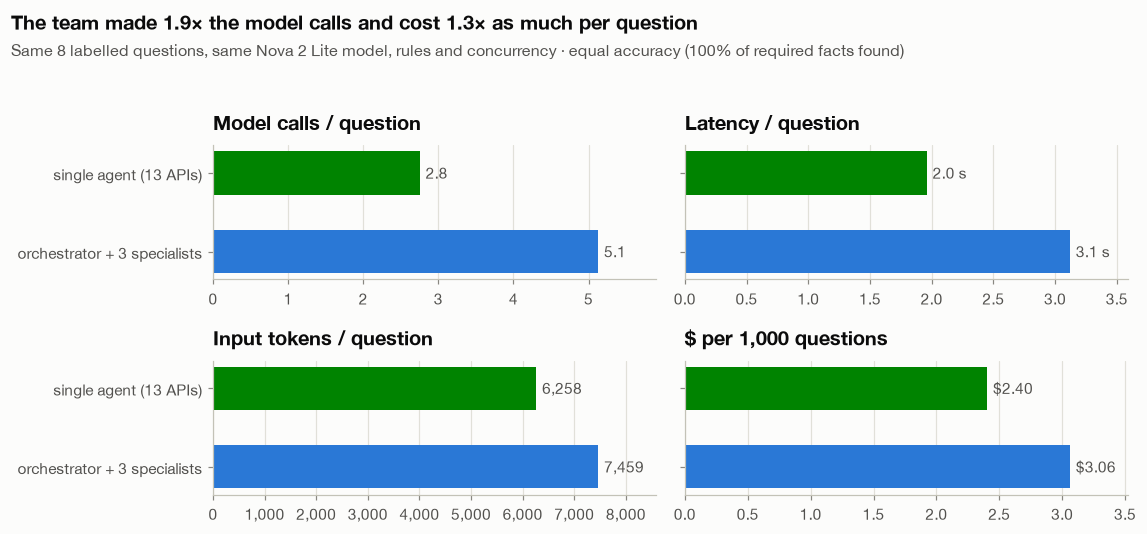

Team vs single agent on the same 8 questions: accuracy 100% vs 100% · 1.9× model calls · 1.2× input tokens · 1.6× latency · 1.27× cost per question
Answers with an invented follow-up promise: team 0/8, single agent 1/8
  ⚠ single agent (13 APIs) · CRD-1: “You'll receive an email with next steps and a provisional credit will be applied while this is resolved.”


In [11]:
EVAL_ARCHS = {"single agent (13 APIs)": single_results, "orchestrator + 3 specialists": multi_results}
EVAL_PANELS = [("Model calls / question", "model_calls", "{:.1f}", 1), ("Latency / question", "latency_s", "{:.1f} s", 1),
               ("Input tokens / question", "input_tokens", "{:,.0f}", 1), ("$ per 1,000 questions", "cost_usd", "${:.2f}", 1000)]
team_avg, single_avg = multi_results.mean(numeric_only=True), single_results.mean(numeric_only=True)
team_vs_single = team_avg / single_avg
eval_n_questions = len(multi_results)

cost_ratio = team_vs_single.cost_usd
cost_words = (f"cost {cost_ratio:.1f}× as much per question" if cost_ratio >= 1.05
              else f"was {1 / cost_ratio:.1f}× cheaper per question" if cost_ratio <= 0.95 else "cost about the same per question")
accuracy_words = (f"equal accuracy ({team_avg.score:.0%} of required facts found)"
                  if abs(team_avg.score - single_avg.score) < 1e-9
                  else f"accuracy {team_avg.score:.0%} (team) vs {single_avg.score:.0%} (single agent)")

fig, axes = plt.subplots(2, 2, figsize=(10.5, 4.9))
for ax, (panel_title, panel_col, panel_fmt, panel_scale) in zip(axes.flat, EVAL_PANELS):
    viz.hbar(list(EVAL_ARCHS), [df[panel_col].mean() * panel_scale for df in EVAL_ARCHS.values()],
             colors=[MONOLITH_COLOR, viz.ROLE_COLORS["orchestrator"]], fmt=panel_fmt, title=panel_title, ax=ax)
for ax in axes[:, 1]:
    ax.tick_params(labelleft=False)
fig.suptitle(f"The team made {team_vs_single.model_calls:.1f}× the model calls and {cost_words}",
             x=0.01, y=0.985, ha="left", fontsize=13, fontweight="bold")
fig.text(0.01, 0.9, f"Same {eval_n_questions} labelled questions, same Nova 2 Lite model, rules and concurrency · "
         f"{accuracy_words}", ha="left", fontsize=10.5, color=viz.INK_2)
plt.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()

print(f"Team vs single agent on the same {eval_n_questions} questions: accuracy {team_avg.score:.0%} vs {single_avg.score:.0%} · "
      f"{team_vs_single.model_calls:.1f}× model calls · {team_vs_single.input_tokens:.1f}× input tokens · "
      f"{team_vs_single.latency_s:.1f}× latency · {team_vs_single.cost_usd:.2f}× cost per question")
print(f"Answers with an invented follow-up promise: team {int(multi_results.promises.gt(0).sum())}/{eval_n_questions}, "
      f"single agent {int(single_results.promises.gt(0).sum())}/{eval_n_questions}")
for design_name, design_results in EVAL_ARCHS.items():
    for flagged_row in design_results[design_results.promises > 0].itertuples():
        print(f"  ⚠ {design_name} · {flagged_row.id}: “{promise_context(flagged_row.answer)}”")

**How to read the dashboard:** the title is **this run's price of the split**, from the ledger: each specialist
re-sends its own prompt and tools (slide 8: the benefits are *earned with good engineering, not free*). The promise
line counts answers that promise an email nobody will send.

---
## §8 — AgentCore Memory, part 1: one memory, two specialists
*Deck slides 26–34, 39.* The orchestrator and two specialists share **one AgentCore Memory** (created in §0). Each
agent writes its turns as **events** under its own `actor_id` in a shared `session_id`: short-term memory, kept for
7 days (`eventExpiryDuration`, set in §0). Strategies extract long-term **records** **asynchronously** into the
customer's namespaces, `/customers/{customerid}/…`, which every agent searches.

In [12]:
import re
import uuid
from datetime import datetime, timezone

import matplotlib.pyplot as plt
from botocore.exceptions import BotoCoreError, ClientError
from IPython.display import Pretty
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch
from bedrock_agentcore.memory import MemorySessionManager

LEDGER.clear_section("§8")                                       # re-running §8 must not double count in §9
MEMORY_READY = False                                             # every §8 cell below checks this flag
EVENTS, LTM = pd.DataFrame(), pd.DataFrame()                     # §9 reads both: filled in 8.7 and 8.8
MEMORY_RETRIEVALS = {"calls": 0, "records": 0}                  # RetrieveMemoryRecords usage, for the cost line
STRATEGY_NAMES: dict[str, str] = {}                              # strategyId -> strategy name
CUSTOMER_ID = "CUST-1001"                                        # Sofia Martinez (fictional)
CUSTOMER_PATH = f"/customers/{CUSTOMER_ID.lower()}/"             # her subtree of long-term memory


def clear_previous_run(manager: MemorySessionManager, paths=(CUSTOMER_PATH, "/agents/"), max_wait: float = 150):
    """A re-run of §8 must start from an empty long-term memory. Records of the previous run's last turns appear
    ~1.5 min after them, and deleted records stay in list and search results for ~1 min: wait for both."""
    settle = 100 - (time.time() - globals().get("MEMORY_LAST_WRITE", {}).get("t", 0.0))
    if settle > 0:                                               # the previous run's extraction is still running
        print(f"Re-run: waiting {settle:.0f}s for the previous run's last turns to be extracted, then clearing them")
        time.sleep(settle)
    deleted = set()
    for path in paths:
        stale = manager.list_long_term_memory_records(namespace_path=path, max_results=100)
        for i in range(0, len(stale), 100):                      # BatchDeleteMemoryRecords: max 100 per call
            manager.batch_delete_memory_records(memoryId=MEMORY_ID, records=[
                {"memoryRecordId": r["memoryRecordId"], "namespace": r["namespaces"][0]} for r in stale[i:i + 100]])
        deleted |= {r["memoryRecordId"] for r in stale}
    if not deleted:
        return
    print(f"Re-run: deleted {len(deleted)} record(s) left by the previous run; waiting for list and search to drop them")
    t0 = time.time()
    while time.time() - t0 < max_wait:
        seen = {r["memoryRecordId"] for path in paths
                for r in manager.list_long_term_memory_records(namespace_path=path, max_results=100)}
        seen |= {h["memoryRecordId"] for h in manager.search_long_term_memories(
            query="customer contact preference and plans", namespace_path=CUSTOMER_PATH, top_k=20)}
        if not seen & deleted:
            break
        time.sleep(10)
    print(f"  ... {'gone' if not seen & deleted else 'still visible'} after {time.time() - t0:.0f}s")


def open_shared_memory() -> tuple[dict, MemorySessionManager]:
    """Create the memory if §0 did not, wait until ACTIVE, and clear what a previous run of §8 left behind."""
    global MEMORY_ID
    if not globals().get("MEMORY_ID"):
        print("No memory from §0 (M01_CREATE_MEMORY=0, or CreateMemory failed) -> creating it now (~2-4 min).")
        MEMORY_ID = create_shared_memory()
    description = wait_memory_active(timeout=360)
    manager = MemorySessionManager(memory_id=MEMORY_ID, region_name=REGION, boto3_session=SESSION)
    try:
        clear_previous_run(manager)
    except ClientError as e:
        print(f"Could not clear the previous run's records ({e.response['Error']['Code']}); they may show up below.")
    return description, manager

In [13]:
if "wait_memory_active" not in globals():
    print("⚠ §8 skipped: run §0 first, including the 'Early start (2/2)' memory cell.")
else:
    try:
        memory_description, session_manager = open_shared_memory()
        MEMORY_READY = True
    except (ClientError, BotoCoreError, RuntimeError, TimeoutError) as e:
        print(f"⚠ §8 skipped: AgentCore Memory is unavailable ({type(e).__name__}: "
              f"{mc.short(e.response['Error']['Message'] if isinstance(e, ClientError) else e, 110)}).\n"
              "  Every §8 cell below checks MEMORY_READY and does nothing. Continue with §9; §10 still cleans up.")

if MEMORY_READY:
    STRATEGY_NAMES = {s["strategyId"]: s["name"] for s in memory_description["strategies"]}
    display(pd.DataFrame([{"strategy": s["type"], "name": s["name"], "namespace template": s["namespaceTemplates"][0],
                           "status": s["status"]} for s in memory_description["strategies"]]))

Memory MLADAS_M01_20260928_091109_55e9-dwRiFG71WK is ACTIVE (checked 177s after CreateMemory).


,strategy,name,namespace template,status
0,EPISODIC,AgentEpisodes,/agents/{actorId}/episodes/{sessionId}/,ACTIVE
1,SEMANTIC,CustomerFacts,/customers/{customerid}/facts/,ACTIVE
2,USER_PREFERENCE,CustomerPreferences,/customers/{customerid}/preferences/,ACTIVE
3,SUMMARIZATION,SessionSummaries,/customers/{customerid}/sessions/{sessionId}/,ACTIVE


### 8.3 The hooks and the team (slide 32)
Memory lives in **Strands hooks**. `ShortTermMemoryHook` loads this session's turns from **every** team actor at
start-up and writes each new turn with `CreateEvent`. `LongTermMemoryHook` searches the customer's namespaces on
each user turn and prepends the hits. `memory_hooks()`, at the bottom of the cell, is slide 32 in one function:
**one shared `memory_id` and `session_id` for the whole team, and a distinct `actor_id` per agent**. Only the orchestrator tags its events with
`{customerid}`, so customer facts come from Sofia's own words. The team's tools, prompts and Day-1 driver are
collapsed.

In [14]:
MEMORY_TAG = "customer_memory"
MEMORY_BLOCK = re.compile(rf"<{MEMORY_TAG}>.*?</{MEMORY_TAG}>\s*", flags=re.I | re.S)
MEMORY_TRACE: list[str] = []                                     # what each agent loaded (shown per turn)
MEMORY_READY_AT: dict[str, pd.Timestamp] = {}                    # when each wait for LTM succeeded
MEMORY_LAST_WRITE = globals().get("MEMORY_LAST_WRITE") or {"t": 0.0}   # last CreateEvent (for a clean re-run)


def without_memory(text: str) -> str:
    """Remove injected memory blocks (and any the model echoes back) so they never land in STM or replies."""
    return MEMORY_BLOCK.sub("", text).strip()


def text_blocks(message: dict) -> str:
    """Only the human-readable text of a message (skips toolUse/toolResult blocks and memory blocks)."""
    return "\n".join(t for b in message.get("content", []) if "text" in b and (t := without_memory(b["text"])))


def record_text(record: dict) -> str:
    """Preference records are JSON ({"context", "preference", ...}); summaries wrap topics in <topic name="..."> tags."""
    text = record["content"]["text"]
    try:
        return json.loads(text).get("preference", text)
    except (json.JSONDecodeError, AttributeError):
        return re.sub(r'<topic name="([^"]*)">\s*', r"[\1] ", text).replace("</topic>", "").strip()


def search_memory(memory_session=None, **search) -> list[dict]:
    """RetrieveMemoryRecords (semantic search), counted for the cost line. Slide 34 resilience: [] on errors."""
    try:
        hits = (memory_session or session_manager).search_long_term_memories(**search)
    except ClientError as e:
        print(f"LTM search unavailable ({e.response['Error']['Code']}); continuing without it")
        return []
    MEMORY_RETRIEVALS["calls"] += 1
    MEMORY_RETRIEVALS["records"] += len(hits)
    return hits


def ltm_records(namespace_path: str) -> list[dict]:
    """ListMemoryRecords over a namespace subtree (namespacePath), only records of this story; [] on errors."""
    try:
        records = session_manager.list_long_term_memory_records(namespace_path=namespace_path, max_results=100)
    except ClientError as e:
        print(f"ListMemoryRecords unavailable ({e.response['Error']['Code']})")
        return []
    started = globals().get("STORY_STARTED")                    # ignore anything a previous run left behind
    return [r for r in records if started is None or pd.Timestamp(r["createdAt"]) >= started]


def readable_namespace(namespace: str) -> str:
    """'/customers/cust-1001/sessions/sofia-day3-2026…/' -> '/customers/cust-1001/sessions/<day 3>/'."""
    for day, session_id in globals().get("SESSIONS", {}).items():
        namespace = namespace.replace(session_id, f"<{day.lower()}>")
    return namespace


def ltm_table(records: list[dict], width: int = 100) -> pd.DataFrame:
    return pd.DataFrame([{"strategy": STRATEGY_NAMES.get(r["memoryStrategyId"], "?"),
                          "namespace": readable_namespace(r["namespaces"][0]),
                          "record": mc.short(record_text(r), width)} for r in records],
                        columns=["strategy", "namespace", "record"])


def wait_for_records(namespace_path: str, ready, *, label: str, max_wait: float = 240, poll: float = 10) -> list[dict]:
    """Poll a namespace subtree until ready(records) or max_wait, on ONE status line that updates in place."""
    t0, status = time.time(), display(Pretty("waiting for long-term memory ..."), display_id=True)
    while True:
        records = ltm_records(namespace_path)
        done = ready(records)
        counts = pd.Series([STRATEGY_NAMES.get(r["memoryStrategyId"], "?") for r in records], dtype=object).value_counts()
        summary = "  ·  ".join(f"{k}: {v}" for k, v in counts.items()) or "no records yet"
        status.update(Pretty(f"{time.time() - t0:4.0f}s  {summary}" + ("   -> ready" if done else "")))
        if done:
            MEMORY_READY_AT[label] = pd.Timestamp.now(tz="UTC")
            return records
        if time.time() - t0 >= max_wait:
            print(f"Not ready after {max_wait:.0f}s: extraction is eventually consistent (slide 28). "
                  "Continuing with what is there.")
            return records
        time.sleep(poll)


def learned(*clues: set[str]):
    """ready() test that reads the way the agents do: each clue must be LISTED in a customer namespace and FOUND
    by the same standing-query search the agents run (search can lag the list by up to a minute)."""
    def ready(records: list[dict]) -> bool:
        listed = [r["content"]["text"].lower() for r in records if r["namespaces"][0] in CUSTOMER_NAMESPACES]
        if not all(any(word in text for text in listed for word in clue) for clue in clues):
            return False
        found = [h["content"]["text"].lower() for ns, query in STANDING_QUERIES.items()
                 for h in search_memory(query=query, namespace=ns, top_k=5)]
        return all(any(word in text for text in found for word in clue) for clue in clues)
    return ready


def ltm_frame() -> pd.DataFrame:
    """Every long-term record of this story: the customer's subtree plus each agent's own subtree."""
    records = ltm_records(CUSTOMER_PATH) + [r for actor in TEAM for r in ltm_records(f"/agents/{actor}/")]
    return pd.DataFrame([{"strategy": STRATEGY_NAMES.get(r["memoryStrategyId"], "?"),
                          "namespace": readable_namespace(r["namespaces"][0]),
                          "createdAt": pd.Timestamp(r["createdAt"]).tz_convert("UTC"), "record": record_text(r)}
                         for r in records], columns=["strategy", "namespace", "createdAt", "record"])

In [15]:
from bedrock_agentcore.memory.session import MemorySession
from strands import ToolContext, tool
from strands.hooks import AgentInitializedEvent, HookProvider, HookRegistry, MessageAddedEvent

NAMESPACE_VARS = {"customerid": CUSTOMER_ID.lower()}             # keys and values must be lowercase
CUSTOMER_NAMESPACES = [CUSTOMER_NS_TEMPLATES[k].format(**NAMESPACE_VARS) for k in ("preferences", "facts")]
STANDING_QUERIES = {                                             # slide 34 "core context" every agent should see
    CUSTOMER_NAMESPACES[0]: "How does the customer want to be contacted and kept informed?",
    CUSTOMER_NAMESPACES[1]: "What is the customer planning (projects, dates, amounts), and what is open?",
}
MEMORY_ORCHESTRATOR, LENDING, CARDS = "bank_orchestrator", "lending_specialist", "cards_specialist"
TEAM = [MEMORY_ORCHESTRATOR, LENDING, CARDS]                     # actor_id == agent name: one identity everywhere


def session_turns(memory_sessions: list[MemorySession], k: int = 12) -> list[dict]:
    """The last k conversational events of one session across several actors, oldest first."""
    turns = []
    for ms in memory_sessions:
        for event in ms.list_events(max_results=k):              # ListEvents: newest first, one actor at a time
            for item in event["payload"]:
                if "conversational" in item:
                    turns.append({"ts": event["eventTimestamp"], "actor": ms["actorId"],
                                  "role": item["conversational"]["role"],
                                  "text": item["conversational"]["content"]["text"]})
    return sorted(turns, key=lambda t: t["ts"])[-k:]            # chronological across actors


class ShortTermMemoryHook(HookProvider):
    """Slide 33's hook, fixed: reads the whole team's turns in this session and writes text-only turns."""

    def __init__(self, memory_session: MemorySession, memory_id: str, *, peers: list[MemorySession] = (),
                 namespace_variables: dict[str, str] | None = None, k: int = 12):
        self.memory_session, self.memory_id, self.peers, self.k = memory_session, memory_id, list(peers), k
        self.actor_id, self.session_id = memory_session["actorId"], memory_session["sessionId"]
        self.extraction = {"extractionConfig": {"namespaceVariables": namespace_variables}} if namespace_variables else {}

    def register_hooks(self, registry: HookRegistry, **kwargs) -> None:
        registry.add_callback(AgentInitializedEvent, self.load_session)
        registry.add_callback(MessageAddedEvent, self.save_turn)

    def load_session(self, event: AgentInitializedEvent) -> None:
        try:
            turns = session_turns([self.memory_session, *self.peers], self.k)   # every team actor
        except ClientError as e:                                  # slide 34: degrade, don't fail
            print(f"[{self.actor_id}] STM unavailable: {e.response['Error']['Code']}")
            turns = []
        if turns:
            history = "\n".join(f"[{t['actor']}] {t['role']}: {t['text']}" for t in turns)
            event.agent.system_prompt += ("\n\nEarlier in this support session (AgentCore short-term memory, "
                                          f"oldest first):\n{history}")
        sources = sorted({t["actor"] for t in turns})
        MEMORY_TRACE.append(f"{self.actor_id} · STM: {len(turns)} earlier turn(s) in this session"
                            + (f" from {', '.join(sources)}" if sources else ""))

    def save_turn(self, event: MessageAddedEvent) -> None:
        text = text_blocks(event.message)                         # skip toolUse / toolResult blocks
        if not text:
            return
        role = "USER" if event.message["role"] == "user" else "ASSISTANT"
        try:
            session_manager.create_event(                        # raw CreateEvent: supports extractionConfig
                memoryId=self.memory_id, actorId=self.actor_id, sessionId=self.session_id,
                eventTimestamp=datetime.now(timezone.utc),
                payload=[{"conversational": {"content": {"text": text}, "role": role}}], **self.extraction)
            MEMORY_LAST_WRITE["t"] = time.time()
        except ClientError as e:
            print(f"[{self.actor_id}] memory write failed: {e.response['Error']['Code']}")


class LongTermMemoryHook(HookProvider):
    """Before the model sees a user turn, prepend the customer's long-term memories (top-k per query)."""

    def __init__(self, memory_session: MemorySession, standing_queries: dict[str, str], top_k: int = 5):
        self.memory_session, self.standing_queries, self.top_k = memory_session, standing_queries, top_k

    def register_hooks(self, registry: HookRegistry, **kwargs) -> None:
        registry.add_callback(MessageAddedEvent, self.recall)

    def recall(self, event: MessageAddedEvent) -> None:
        turn = text_blocks(event.message)
        if event.message["role"] != "user" or not turn:
            return
        hits = []
        for namespace, standing_query in self.standing_queries.items():
            for query in (turn, standing_query):                  # relevant now + core context
                hits += [record_text(r) for r in search_memory(self.memory_session, query=query,
                                                               namespace=namespace, top_k=self.top_k)]
        hits = list(dict.fromkeys(hits))
        MEMORY_TRACE.append(f"{self.memory_session['actorId']} · LTM: {len(hits)} record(s)"
                            + "".join(f"\n      · {mc.short(h, 100)}" for h in hits))
        if hits:
            memory_block = "\n".join(f"- {h}" for h in hits)
            event.message["content"].insert(0, {"text": f"<{MEMORY_TAG}>\n{memory_block}\n</{MEMORY_TAG}>"})


def memory_hooks(actor_id: str, session_id: str, *, customer_facing: bool = False) -> list[HookProvider]:
    """Same memory_id, same session_id, this agent's own actor_id."""
    memory_session = session_manager.create_memory_session(actor_id=actor_id, session_id=session_id)
    peers = [session_manager.create_memory_session(actor_id=a, session_id=session_id) for a in TEAM if a != actor_id]
    return [ShortTermMemoryHook(memory_session, MEMORY_ID, peers=peers,
                                namespace_variables=NAMESPACE_VARS if customer_facing else None),
            LongTermMemoryHook(memory_session, STANDING_QUERIES)]

In [16]:
# the memory team: least-privilege tools, prompts, specialists as tools
@tool
def list_customer_applications(customer_id: str) -> list[dict]:
    """Loan applications of a customer: id, product, amount, status and submission date.

    Args:
        customer_id: Bank customer id, e.g. "CUST-1001".
    """
    return [{"application_id": app_id, **app} for app_id, app in bank.LOAN_APPLICATIONS.items()
            if app["customer_id"] == customer_id]


@tool
def open_case(customer_id: str, case_type: str, summary: str, amount: float | None = None) -> dict:
    """Open a case in the bank's case-management system; returns the existing open case if it is a repeat.

    Args:
        customer_id: Bank customer id.
        case_type: One of "billing_dispute", "fraud", "complaint".
        summary: One-sentence description of the case.
        amount: Disputed amount in USD, if any.
    """
    for case in bank.CASES.values():                            # agents retry: side effects must be idempotent
        if (case["customer_id"], case["type"], case["amount"], case["status"]) == (customer_id, case_type, amount, "open"):
            return case
    return bank.open_case(customer_id, case_type, summary, amount)


LENDING_TOOLS = [tool(bank.get_loan_products), tool(bank.monthly_payment), tool(bank.get_application),
                 list_customer_applications]
CARDS_TOOLS = [tool(bank.find_duplicate_charges), tool(bank.get_dispute_policy), open_case]

FORMAT_RULES = ("Background from long-term memory may appear at the start of a message inside <customer_memory> "
                "tags: use it, but never write such tags yourself. Answer in at most 4 sentences of plain prose. "
                "No headings, no lists, no markdown.")
LENDING_PROMPT = (
    "You are the AnyCompany Bank lending specialist for loans and loan applications. Use your tools for every rate, "
    "payment and status; never compute a payment yourself. Always call list_customer_applications and mention any "
    "open application with its id and status. Relate the answer to the customer's known plans and timeline, and "
    "follow the customer's contact preference. " + FORMAT_RULES)
CARDS_PROMPT = (
    "You are the AnyCompany Bank cards specialist for card transactions, duplicate charges and disputes. For a "
    "suspected duplicate charge: call find_duplicate_charges and get_dispute_policy, then open_case once with case_type "
    "'billing_dispute' and the duplicate amount. Reply with the case id and the provisional-credit timeline, follow the "
    "customer's contact preference and relate the timeline to the customer's known plans. " + FORMAT_RULES)
MEMORY_ORCHESTRATOR_PROMPT = (
    f"You are the AnyCompany Bank customer-service orchestrator. Signed-in customer: {CUSTOMER_ID}, card ending 4417. "
    "Send lending questions (loans, rates, payments, loan applications) to lending_specialist and card questions "
    "(transactions, duplicate charges, disputes) to cards_specialist; include the customer id, the card ending and all "
    "relevant details in the query. Reply to the customer with the specialist's result, say how we will follow up "
    "using the customer's preferred channel if one is known, and connect the answer to the customer's known plans "
    "when relevant. Do not use the customer's name. " + FORMAT_RULES)
SPECIALIST_REPLIES: list[tuple[str, list[str], str]] = []


def ask_specialist(actor_id: str, system_prompt: str, tools: list, query: str, session_id: str) -> str:
    """Slide 33, fixed: a specialist with memory hooks on the shared memory, called as a tool."""
    try:
        specialist = make_agent(actor_id, system_prompt, tools=tools, hooks=memory_hooks(actor_id, session_id),
                                state={"actor_id": actor_id, "session_id": session_id})
        reply, calls = without_memory(text_of(specialist(query))), tool_calls(specialist)
    except Exception as e:                                        # graceful degradation (slide 12)
        reply, calls = f"Error in {actor_id}: {e}", []
    SPECIALIST_REPLIES.append((actor_id, calls, reply))
    return reply


@tool(context=True)
def lending_specialist(query: str, tool_context: ToolContext) -> str:
    """Loans at AnyCompany Bank: products, APR ranges, monthly payments and the status of the customer's loan applications.

    Args:
        query: The lending question with the customer id and every relevant detail.
    """
    return ask_specialist(LENDING, LENDING_PROMPT, LENDING_TOOLS, query, tool_context.agent.state.get("session_id"))


@tool(context=True)
def cards_specialist(query: str, tool_context: ToolContext) -> str:
    """Cards at AnyCompany Bank: card transactions, duplicate charges and billing disputes.

    Args:
        query: The card question with the customer id, the card ending and every relevant detail.
    """
    return ask_specialist(CARDS, CARDS_PROMPT, CARDS_TOOLS, query, tool_context.agent.state.get("session_id"))


def make_memory_orchestrator(session_id: str):
    return make_agent(MEMORY_ORCHESTRATOR, MEMORY_ORCHESTRATOR_PROMPT, tools=[lending_specialist, cards_specialist],
                      hooks=memory_hooks(MEMORY_ORCHESTRATOR, session_id, customer_facing=True),
                      state={"actor_id": MEMORY_ORCHESTRATOR, "session_id": session_id})

### 8.4 Sofia's week, Day 1 (slide 39)

Slide 39 tells this story at an online shop; here it happens at the bank. Sofia (`CUST-1001`) contacts the bank
three times. Each day is a **new session**, so short-term memory starts empty; only long-term memory can carry
Day 1 into Day 3 and Day 7.

| Identifier | Value in this demo | Analogy |
|---|---|---|
| `memory_id` | the memory created in §0 | the building |
| `session_id` | one per day: `sofia-day1-…`, `sofia-day3-…`, `sofia-day7-…` | a meeting room |
| `actor_id` | `bank_orchestrator`, `lending_specialist`, `cards_specialist` | a name badge |

In [17]:
# Sofia's three sessions and run_day() (orchestrator -> specialists, all with memory hooks), then Day 1
STORY_ID = f"{RUN_ID}-{uuid.uuid4().hex[:4]}"                     # fresh sessions on every re-run
SESSIONS = {day: f"sofia-{day.lower().replace(' ', '')}-{STORY_ID}" for day in ("Day 1", "Day 3", "Day 7")}
SOFIA = {
    "Day 1": ("Hi! I'm planning a kitchen remodel that starts in November and I'm looking at a home improvement loan "
              "of about $25,000. What APR range can I expect, and what would the monthly payment be over 60 months "
              "at the lowest rate? Please send any follow-ups by email only; I can't take calls at work."),
    "Day 3": ("Hi again. I see two identical charges from Harbor Electronics on my card. Please fix it and keep me "
              "posted. I need that money back before my project starts."),
    "Day 7": "Any update on my application?",
}
ANSWERS: dict[str, str] = {}
STORY_STARTED = pd.Timestamp.now(tz="UTC")                       # records created before this are not Sofia's week
bank.reset_state()                                               # the cards specialist opens a case on Day 3


def run_day(day: str) -> str:
    """One customer turn in a brand-new session: orchestrator -> specialist(s), all with memory hooks."""
    MEMORY_TRACE.clear(); SPECIALIST_REPLIES.clear()
    try:
        orchestrator = make_memory_orchestrator(SESSIONS[day])
        with LEDGER.scope("§8 shared memory"):
            ANSWERS[day] = without_memory(text_of(orchestrator(SOFIA[day])))
    except Exception as e:                                        # keep "Run All" going (slide 12)
        ANSWERS[day] = f"(the orchestrator failed: {type(e).__name__}: {mc.short(e, 160)})"
    viz.chat(f"Sofia ({CUSTOMER_ID}) · {day} · session_id = {SESSIONS[day]}", SOFIA[day], role="customer")
    viz.chat("AgentCore Memory · what each agent loaded", "\n".join(MEMORY_TRACE), role="system")
    for actor, calls, reply in SPECIALIST_REPLIES:
        viz.chat(f"{actor} (called as a tool; used {' → '.join(calls) or 'no tools'})", mc.short(reply, 320), role="agent")
    viz.chat(f"{MEMORY_ORCHESTRATOR} → Sofia", ANSWERS[day], role="agent")
    return ANSWERS[day]


if MEMORY_READY:
    run_day("Day 1")
else:
    print("§8 skipped: AgentCore Memory is unavailable (see the first §8 cell).")

**What to notice (Day 1):** the specialist's memory line shows it loaded the orchestrator's turn from **short-term
memory**: same `session_id`, different `actor_id`. Long-term memory is still empty: extraction runs in the
background (1 to 2.5 min in our test runs). We come back after the Graph. If the reply promises an email, that is
by design: Sofia asked for email, and the §8 prompts tell the team to use her channel. But no tool in this team sends
email, so by §2's check only a notification tool or a person can keep that promise.

---
## §3 — Agent to agent: the partner's agent over A2A on AgentCore Runtime
*Deck slides 9, 18, 25.* Now the specialist belongs to **another company**, the Octank Credit Bureau, so the agents
need a protocol: **Agent2Agent (A2A)**. §0 deployed Octank's agent to AgentCore Runtime (`serverProtocol="A2A"`,
its own IAM role).

### 3.2–3.3 The partner's code, deploy facts and health check
The first cell prints the partner's side: an Agent Card, a `StrandsA2AExecutor`, `serve_a2a`.

In [18]:
LEDGER.clear_section("§3")                 # re-running §3 must not double count in the §9 dashboard

import inspect
from IPython.display import Code, HTML

PARTNER_DIR = NOTEBOOK_DIR / "partner_credit_bureau"
partner_reqs = [ln for ln in (PARTNER_DIR / "requirements.txt").read_text().splitlines() if ln and not ln.startswith("#")]
partner_main = (PARTNER_DIR / "agent.py").read_text().split('if __name__ == "__main__":')[1].rstrip()

display(Code("\n\n".join([
    "# requirements.txt (installed as linux/arm64 wheels):  " + "  ".join(partner_reqs) + "\n"
    "# build_agent(context_id) -> a Strands Agent on Nova 2 Lite with two PRIVATE tools: get_credit_report, risk_band",
    inspect.getsource(bureau_code.agent_card).rstrip(),
    inspect.getsource(bureau_code.executor).rstrip(),
    'if __name__ == "__main__":' + partner_main,
]), language="python"))

# requirements.txt (installed as linux/arm64 wheels):  strands-agents[a2a]==1.57.1  bedrock-agentcore[a2a]==1.23.1
# build_agent(context_id) -> a Strands Agent on Nova 2 Lite with two PRIVATE tools: get_credit_report, risk_band

def agent_card(url: str = "http://localhost:9000/") -> AgentCard:
    """The public business card of this agent — what any A2A client discovers first."""
    return AgentCard(
        name="Octank Credit Bureau",
        description="Partner credit bureau. Returns a credit summary and risk band for a bureau reference id.",
        url=url,
        version="1.0.0",
        capabilities=AgentCapabilities(streaming=True),
        default_input_modes=["text"],
        default_output_modes=["text"],
        skills=[AgentSkill(id="credit_summary", name="Credit summary",
                           description="Credit score, risk band, delinquencies and utilization for a bureau ref id.",
                           tags=["credit", "lending", "risk"],
                           examples=["Credit summary for BR-77410"])],
    )

def executor() -> StrandsA2AExecutor:
    return StrandsA2AExecutor(agent_factory=build_agent, enable_a2a_compliant_streaming=True)

if __name__ == "__main__":
    from bedrock_agentcore.runtime import serve_a2a

    # AgentCore Runtime proxies A2A traffic to port 9000; bind all interfaces inside the microVM.
    serve_a2a(executor(), agent_card(os.getenv("AGENTCORE_RUNTIME_URL", "http://localhost:9000/")),
              host="0.0.0.0", port=9000)

In [19]:
# ONE decision for the whole section: the Runtime-hosted partner if READY *and* healthy, else the local backup (§0)
if bureau_job is not None and not bureau_job.ready and bureau_job.status != "FAILED":
    print(f"Waiting for {bureau_job.name} ({bureau_job.status}), at most 4 min ...")
# A fresh runtime session on purpose (the default reuses §0's warm probe session), so 3.5 can show cold vs warm
bureau_a2a, BUREAU_WHERE = get_bureau_agent(wait_s=240, name="octank_credit_bureau",
                                            session_id=mc.runtime_session_id("anycompany-a2a"))
ON_RUNTIME = BUREAU_WHERE == "AgentCore Runtime"
BUREAU_URL = bureau_a2a.endpoint           # the runtime's invocation URL, or http://127.0.0.1:<port>/ on the fallback
print("Partner agent:", BUREAU_WHERE)

Partner agent: AgentCore Runtime


In [20]:
if ON_RUNTIME:
    bureau_control = SESSION.client("bedrock-agentcore-control")
    runtime_desc = bureau_control.get_agent_runtime(agentRuntimeId=bureau_job.runtime_id)
    bureau_endpoints = bureau_control.list_agent_runtime_endpoints(agentRuntimeId=bureau_job.runtime_id)["runtimeEndpoints"]
    bureau_role_policy = SESSION.client("iam").get_role_policy(RoleName=bureau_job.role_name,
                                                        PolicyName="agentcore-runtime")["PolicyDocument"]
    BUREAU_PLATFORM = runtime_desc.get("platformVersion", "V1")
    code_cfg, bureau_lifecycle = runtime_desc["agentRuntimeArtifact"]["codeConfiguration"], runtime_desc["lifecycleConfiguration"]
    deploy_step_at: dict[str, float] = {}
    for ts, step, _ in bureau_job.progress():
        deploy_step_at.setdefault(step, ts)

    def deploy_step_took(a: str, b: str) -> str:
        return f"{deploy_step_at[b] - deploy_step_at[a]:.1f} s" if a in deploy_step_at and b in deploy_step_at else "n/a"

    deploy_facts = pd.DataFrame({"value": {
        "serverProtocol · platform": f"{runtime_desc['protocolConfiguration']['serverProtocol']} · {BUREAU_PLATFORM}",
        "inbound auth": "OAuth 2.0 / JWT (customJWTAuthorizer)" if runtime_desc.get("authorizerConfiguration")
                        else "IAM SigV4 (the default: no JWT authorizer configured)",
        "version → endpoints": f"version {runtime_desc['agentRuntimeVersion']} · " + ", ".join(
            f"{e['name']} → version {e.get('liveVersion', '?')}" for e in bureau_endpoints),
        "artifact": f"{code_cfg['runtime']} · {code_cfg['entryPoint'][0]} · code.zip in S3 (no Docker, no ECR)",
        "execution role (this agent only)": mc.mask_account(bureau_job.role_name, ACCOUNT),
        "role policy statements": ", ".join(s["Sid"] for s in bureau_role_policy["Statement"]),
        "session idle timeout / max lifetime": f"{bureau_lifecycle['idleRuntimeSessionTimeout']} s / "
                                               f"{bureau_lifecycle['maxLifetime'] / 3600:.0f} h",
        "deployment (§0, background)": f"{deploy_step_at.get('RUNTIME_READY', float('nan')):.1f} s: package "
            f"{deploy_step_took('PACKAGING', 'UPLOADING')} · upload {deploy_step_took('UPLOADING', 'IAM_ROLE')} · IAM role "
            f"{deploy_step_took('IAM_ROLE', 'CREATE_RUNTIME')} · CreateAgentRuntime → READY {deploy_step_took('CREATE_RUNTIME', 'RUNTIME_READY')}",
    }})
    with pd.option_context("display.max_colwidth", 110):
        display(deploy_facts)
else:
    BUREAU_PLATFORM = None
    fallback_why = ("the deployment is off (M01_DEPLOY_RUNTIME=0)" if bureau_job is None else
                    f"the deployment failed: {mc.short(mc.mask_account(str(bureau_job.error), ACCOUNT), 140)}"
                    if bureau_job.status == "FAILED" else
                    f"the runtime is still {bureau_job.status} after 4 min" if not bureau_job.ready else
                    "the runtime is READY but did not answer the health probe")
    display(HTML(
        f'<div style="border:2px solid {viz.STATUS["warning"]};border-radius:6px;padding:8px 14px;margin:4px 0;'
        f'font-family:system-ui,-apple-system,sans-serif;font-size:14px;line-height:1.5">'
        f'<b>FALLBACK MODE: the partner agent runs on localhost.</b><br>Why: {fallback_why}.<br>'
        f'Same agent code, but no AgentCore endpoint, no SigV4 and no microVM. Every cell below still runs; '
        f'AgentCore-only steps are skipped and say so.</div>'))

,value
serverProtocol · platform,A2A · V1
inbound auth,IAM SigV4 (the default: no JWT authorizer configured)
version → endpoints,version 1 · DEFAULT → version 1
artifact,"PYTHON_3_12 · agent.py · code.zip in S3 (no Docker, no ECR)"
execution role (this agent only),mladas-m01-bureau-2026092809110955e9
role policy statements,"InvokeNova, Logs, Traces, Metrics, WorkloadIdentity"
session idle timeout / max lifetime,900 s / 8 h
"deployment (§0, background)",40.7 s: package 3.2 s · upload 7.2 s · IAM role 0.5 s · CreateAgentRuntime → READY 29.8 s


**What to notice** (on the fallback, the banner replaces this table): the runtime speaks `serverProtocol: A2A`
behind IAM SigV4, and its role allows only Nova, logs, traces, metrics and a workload identity, nothing of the
bank's (slide 10's isolation). `DEFAULT` follows the latest version; a named endpoint per version lets consumers pin
one (slide 9). In our test runs the deployment took 35–50 s, mostly AgentCore provisioning.

### 3.4 Discovery: fetch the Agent Card
An A2A client starts by reading the partner's card. On AgentCore Runtime the card sits behind the runtime's
invocation URL and **every request must be authenticated**: we sign with IAM **SigV4** (service
`bedrock-agentcore`) and send a **session id** header, and each new session gets its own microVM. Then we send the
same GET **unsigned**, and finally call boto3's `get_agent_card`, the same card through the AWS SDK.

In [21]:
# Agent Card discovery: signed cold/warm GET, unsigned GET, boto3 get_agent_card
import httpx

A2A_LATENCY: dict[str, float] = {}                               # measured timings, reused by the 3.6 diagram
CARD_URL = BUREAU_URL + ".well-known/agent-card.json"
DISCOVERY_SESSION = mc.runtime_session_id("anycompany-discovery")    # >= 33 chars; one session id = one microVM
DISCOVERY_HEADERS = {"X-Amzn-Bedrock-AgentCore-Runtime-Session-Id": DISCOVERY_SESSION}
discovery_calls: list[dict] = []


def fetch_bureau_card(label: str, signed: bool) -> httpx.Response:
    t0 = time.perf_counter()
    response = httpx.get(CARD_URL, auth=mc.SigV4HttpxAuth() if signed and ON_RUNTIME else None,
                         headers=DISCOVERY_HEADERS, timeout=60)
    discovery_calls.append({"request": label, "HTTP status": response.status_code,
                            "seconds": round(time.perf_counter() - t0, 2), "response": mc.short(response.text, 44)})
    return response


card_response = fetch_bureau_card("signed GET · new session (microVM starts)" if ON_RUNTIME
                                  else "GET · localhost (no auth)", signed=True)
fetch_bureau_card("signed GET · same session (warm)" if ON_RUNTIME else "GET · localhost, again", signed=True)
A2A_LATENCY.update(card_first=discovery_calls[0]["seconds"], card_second=discovery_calls[1]["seconds"])
bureau_card = card_response.json() if card_response.status_code == 200 else {}

if ON_RUNTIME:
    fetch_bureau_card("UNSIGNED GET", signed=False)
    t0 = time.perf_counter()
    via_sdk = SESSION.client("bedrock-agentcore").get_agent_card(agentRuntimeArn=bureau_job.runtime_arn,
                                                                runtimeSessionId=DISCOVERY_SESSION)
    discovery_calls.append({"request": "boto3 get_agent_card · same session", "HTTP status": via_sdk["statusCode"],
                            "seconds": round(time.perf_counter() - t0, 2),
                            "response": "same card ✓" if via_sdk["agentCard"] == bureau_card else "card differs"})

display(pd.DataFrame(discovery_calls).set_index("request"))
if bureau_card:
    card_view = pd.DataFrame({"value": {
        "name": bureau_card["name"],
        "description": bureau_card["description"],
        "url": mc.middle(mc.mask_account(bureau_card["url"], ACCOUNT), 52, 26),
        "version · protocolVersion": f"{bureau_card['version']} · {bureau_card['protocolVersion']}",
        "preferredTransport": bureau_card.get("preferredTransport"),
        "capabilities": json.dumps(bureau_card.get("capabilities")),
        "skills": "; ".join(f"{s['id']}: {s['description']}" for s in bureau_card.get("skills", [])),
        "securitySchemes": bureau_card.get("securitySchemes", "(none advertised)"),
    }})
    with pd.option_context("display.max_colwidth", 100):
        display(card_view)
else:
    print(f"No card: HTTP {card_response.status_code}. Re-run this cell; if it persists, restart §3 on the fallback.")

,HTTP status,seconds,response
request,,,
signed GET · new session (microVM starts),200,6.65,"{""capabilities"":{""streaming"":true},""default…"
signed GET · same session (warm),200,0.36,"{""capabilities"":{""streaming"":true},""default…"
UNSIGNED GET,403,0.23,"{""message"":""Missing Authentication Token""}"
boto3 get_agent_card · same session,200,0.39,same card ✓


,value
name,Octank Credit Bureau
description,Partner credit bureau. Returns a credit summary and risk band for a bureau reference id.
url,https://bedrock-agentcore.us-east-1.amazonaws.com/ru…5e9-v18Gxr7JOm/invocations
version · protocolVersion,1.0.0 · 0.3.0
preferredTransport,JSONRPC
capabilities,"{""streaming"": true}"
skills,"credit_summary: Credit score, risk band, delinquencies and utilization for a bureau ref id."
securitySchemes,(none advertised)


**What to notice:**
- The **unsigned GET gets 403 at the endpoint** and never reaches the partner's microVM: inbound auth (**AgentCore
  Identity**: IAM SigV4 here, or OAuth 2.0 / JWT) is enforced before any partner code runs.
- A session's **first** request starts its microVM, so it is slow; later requests take well under a second.
- The card advertises **no** `securitySchemes`: the endpoint enforces auth, whatever the card says. (On the localhost
  fallback: no endpoint, no 403, no microVM.)

### 3.5 Call the partner with the Strands `A2AAgent`
`bureau_a2a` (from 3.3) is a Strands **`A2AAgent`** that signs every request with SigV4 and opens its own runtime
session, so its first call is *cold* and its second *warm* (fallback: plain HTTP to localhost); each call times out
after 90 s. **A2A does not carry the partner's token usage back**: the partner pays for its own Nova tokens, so the
ledger records latency only (`LEDGER.add_remote`).

In [22]:
from strands.agent import AgentResult


def ask_bureau(agent: A2AAgent, text: str) -> tuple[AgentResult, float]:
    """One A2A round trip, timed. Remote token usage is not propagated over A2A, so the ledger gets latency only."""
    t0 = time.perf_counter()
    result = agent(text)
    seconds = time.perf_counter() - t0
    LEDGER.add_remote("octank_credit_bureau", seconds, result.stop_reason)
    return result, seconds


def bureau_report(result: AgentResult) -> tuple[dict, str]:
    """Parse the partner's reply with a tolerant reader, and say whether it kept its own contract (ONE bare JSON object)."""
    text = text_of(result).strip()
    try:
        reply = parse_json(text)
    except ValueError:
        return {"raw": text}, "✗ not JSON"
    if text.startswith("{"):
        return reply, "✓ bare JSON"
    return reply, "✗ wrapped in ```json fences" if text.startswith("```") else "✗ extra text around the JSON"


BUREAU_QUESTION = "Credit summary for BR-90315"
viz.chat("AnyCompany Bank → Octank Credit Bureau (A2A)", BUREAU_QUESTION, role="agent")

a2a_attempts = []
with LEDGER.scope("§3 A2A"):
    for n in (1, 2):
        bureau_result, seconds = ask_bureau(bureau_a2a, BUREAU_QUESTION)
        bureau_reply, contract = bureau_report(bureau_result)
        A2A_LATENCY[f"send_{n}"] = round(seconds, 2)
        a2a_attempts.append({
            "call": ("cold (new session)" if n == 1 else "warm (same session)") if ON_RUNTIME else f"call {n} (localhost)",
            "seconds": round(seconds, 2), "result.state": bureau_result.state,
            "stop_reason": bureau_result.stop_reason, "partner kept its JSON contract?": contract})

viz.chat(f"Octank Credit Bureau · {BUREAU_WHERE}", json.dumps(bureau_reply, indent=1), role="remote")
display(pd.DataFrame(a2a_attempts).set_index("call"))

,seconds,result.state,stop_reason,partner kept its JSON contract?
call,,,,
cold (new session),9.40,{'a2a_task_state': 'completed'},end_turn,✗ wrapped in ```json fences
warm (same session),2.23,{'a2a_task_state': 'completed'},end_turn,✗ wrapped in ```json fences


**What to notice:**
- The bank gets the summary and a `completed` task, never the bureau's prompt, tools or raw file.
- **Read the contract column.** In our test runs the partner wrapped its JSON in code fences, breaking its own
  prompt. `parse_json` tolerates it; the fix belongs in the partner SLA (slide 24).
- A2A returns no token usage: the bank sees latency only, and Octank pays for its own inference.

---
## §5 — Graph: a loan decision with code nodes, a remote A2A node and a review loop
*Deck slides 16, 19, 21.* **You define the map, the agents choose the route.** Aisha Patel's loan (`APP-2003`, a
thin credit file) needs deterministic arithmetic, the partner's credit check, and a four-eyes review that must end
with a person. The node code (Nova agents with Pydantic contracts, plain-Python `FunctionNode`s, the partner as an
`A2AAgent`) is collapsed; the wiring is not.

In [23]:
# FunctionNode, Pydantic contracts, tools and prompts of the loan graph
import asyncio
import re
from typing import Any, Callable, Literal, NamedTuple

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pydantic import BaseModel, Field
from strands import ToolContext, tool
from strands.agent import AgentResult
from strands.hooks import AfterNodeCallEvent
from strands.multiagent import GraphBuilder, GraphResult, Status
from strands.multiagent.base import MultiAgentBase, MultiAgentResult, NodeResult
from strands.multiagent.graph import Graph, GraphState
from strands.telemetry.metrics import EventLoopMetrics

LEDGER.clear_section("§5")                    # re-running this section must not double count in §9
# decide_loan() (5.4) reports a failed node itself; without this the SDK also prints a traceback for a handled failure
logging.getLogger("strands.multiagent.graph").setLevel(logging.CRITICAL)


class FunctionNode(MultiAgentBase):
    """A Graph node that runs plain Python instead of a model: fn(text, invocation_state) -> str. Zero tokens."""

    def __init__(self, fn: Callable[[str, dict[str, Any]], str], name: str):
        super().__init__()
        self.fn, self.name, self.id = fn, name, name

    async def invoke_async(self, task, invocation_state: dict[str, Any] | None = None, **kwargs) -> MultiAgentResult:
        started = time.perf_counter()
        # Entry nodes receive the task string; downstream nodes receive content blocks (task + upstream outputs)
        text = task if isinstance(task, str) else "\n".join(block.get("text", "") for block in task)
        output = self.fn(text, invocation_state or {})
        elapsed_ms = round((time.perf_counter() - started) * 1000)
        reply = AgentResult(stop_reason="end_turn", message={"role": "assistant", "content": [{"text": output}]},
                            metrics=EventLoopMetrics(), state={})
        return MultiAgentResult(
            status=Status.COMPLETED, execution_time=elapsed_ms, execution_count=1,
            results={self.name: NodeResult(result=reply, execution_time=elapsed_ms, status=Status.COMPLETED,
                                           execution_count=1)})

In [24]:
# FunctionNode, Pydantic contracts, tools and prompts of the loan graph
# ---- Contracts: Pydantic models -> structured output (never start these names with "_": Nova v1 strips it) ----
class IncomeDebit(BaseModel):
    payee: str = Field(description="Payee as written on the bank statement")
    monthly_amount: float = Field(description="USD per month")
    category: Literal["housing", "loan", "other"] = Field(
        description="housing = rent or mortgage; loan = auto, student or personal loan, card payment; other = anything else")


class IncomeFacts(BaseModel):
    """Figures copied from the pay stub and bank statement. No calculations."""
    gross_pay_per_period: float = Field(description="Gross pay for ONE pay period, from the pay stub")
    pay_frequency: Literal["weekly", "bi-weekly", "semi-monthly", "monthly"]
    recurring_debits: list[IncomeDebit] = Field(description="Every recurring debit on the bank statement")


class UnderwritingDecision(BaseModel):
    """The underwriter's decision record: the contract the reviewer checks."""
    decision: Literal["approve", "decline", "refer"]
    credit_score: int = Field(description="Copied from the bureau summary")
    thin_file: bool = Field(description="Copied from the bureau summary")
    dti: float = Field(description="Copied from the affordability worksheet")
    rationale: str = Field(description="At most two sentences; states the credit score and the DTI")
    conditions: list[str] = Field(description="Short conditions of the offer or referral; empty when declining")


class Review(BaseModel):
    """The policy reviewer's verdict on one decision record. Field order = the order the checker works in."""
    triggers_found: list[str] = Field(description="Manual-review triggers that apply to this record; empty if none")
    required_decision: Literal["approve", "decline", "refer"] = Field(description="The decision the policy requires")
    approved: bool = Field(
        description="True only if the record's decision equals required_decision and the rationale states the score")
    issues: list[str] = Field(description="One short entry per failed check; empty when approved")


# ---- Tools: each reads the application id from invocation_state, never from the prompt ----
@tool(context=True)
def read_income_documents(tool_context: ToolContext) -> dict:
    """Read the pay stub and bank statement of the loan application being decided. Takes no arguments."""
    docs = bank.get_application_documents(tool_context.invocation_state["application_id"])["documents"]
    return {"pay_stub": docs["pay_stub"], "bank_statement": docs["bank_statement"]}


@tool(context=True)
def get_letter_recipient(tool_context: ToolContext) -> dict:
    """First name and preferred contact channel of the applicant being decided. Takes no arguments."""
    application = bank.get_application(tool_context.invocation_state["application_id"])
    customer = bank.get_customer_profile(application["customer_id"])
    return {"first_name": customer["name"].split()[0], "preferred_channel": customer["preferred_channel"]}


# ---- FunctionNode logic: plain Python, zero tokens ----
PAY_PERIODS_PER_YEAR = {"weekly": 52, "bi-weekly": 26, "semi-monthly": 24, "monthly": 12}


def intake_node(text: str, invocation_state: dict) -> str:
    """Entry node. Its output crosses the trust boundary to the partner, so it carries only what is needed."""
    app = bank.get_application(invocation_state["application_id"])
    bureau_ref = bank.get_customer_profile(app["customer_id"])["bureau_ref"]
    return (f"Application {app['application_id']}: {app['product'].replace('_', ' ')} loan, ${app['amount']:,} over "
            f"{app['term_months']} months. Credit summary requested for bureau_ref {bureau_ref}.")


def affordability_node(text: str, invocation_state: dict) -> str:
    """DTI worksheet: the model extracted the figures, code does the arithmetic."""
    facts = IncomeFacts.model_validate(parse_json(text))                  # income_check's structured output
    app = bank.get_application(invocation_state["application_id"])
    stress_apr = bank.LOAN_PRODUCTS[app["product"]]["apr_range"][1]      # top of the product's APR range
    new_payment = bank.monthly_payment(app["amount"], stress_apr, app["term_months"])
    income = facts.gross_pay_per_period * PAY_PERIODS_PER_YEAR[facts.pay_frequency] / 12
    debts = sum(d.monthly_amount for d in facts.recurring_debits if d.category != "other")
    return json.dumps({
        "gross_monthly_income": round(income, 2), "existing_monthly_debt": debts, "stress_apr_pct": stress_apr,
        "new_monthly_payment": new_payment, "dti": round((debts + new_payment) / income, 2),
        "policy": LOAN_POLICY["version"], "min_credit_score": LOAN_POLICY["min_credit_score"][app["product"]],
        "max_dti": LOAN_POLICY["max_dti"]})


def manual_review_node(text: str, invocation_state: dict) -> str:
    """Escalation: the review loop hit its cap without approval, so a named loan officer takes over."""
    review = Review.model_validate(parse_json(text))
    return (f"ESCALATED {invocation_state['application_id']} to loan officer {invocation_state['officer_id']}: not "
            f"approved after {invocation_state['max_revisions']} revision(s). Open issues: {'; '.join(review.issues)} "
            f"No customer message sent.")


# ---- Prompts: role + explicit output format + explicit negatives (the Nova recipe, §2.1) ----
LOAN_POLICY = bank.LENDING_POLICY

INCOME_PROMPT = (
    "You are a document-extraction specialist at AnyCompany Bank. First call read_income_documents. Then copy the "
    "figures exactly as written: gross pay for one pay period, the pay frequency, and every recurring debit on the "
    "bank statement with its category. Do not calculate anything. No commentary.")

UNDERWRITER_PROMPT = (
    "You are the automated underwriter (the maker) in AnyCompany Bank's loan-decision flow. Your input holds the "
    "partner bureau's credit summary (JSON), the bank's affordability worksheet (JSON, computed by code) and, in a "
    "revision round, the policy reviewer's issues.\n"
    "Decide with the hard limits only: 'decline' if the credit score is below min_credit_score or the dti is above "
    "max_dti in the worksheet; otherwise 'approve'. If reviewer issues are present, resolve every issue exactly as "
    "the reviewer requires; that is the only case in which you may choose 'refer'.\n"
    "Copy credit_score and thin_file from the bureau summary and dti from the worksheet; never recompute them. "
    "rationale: at most two sentences that state the credit score and the DTI. conditions: short customer-facing "
    "conditions, such as 'verify employment' for an approval or 'loan officer review' for a referral; never policy "
    "wording; empty when declining. No headings, no markdown.")

REVIEWER_PROMPT = (       # generated from the policy data, so policy and checklist can't drift apart
    f"You are the credit-policy reviewer (the checker) in AnyCompany Bank's four-eyes loan process. You receive one "
    f"underwriting decision record for the loan named in the task and check it against lending policy "
    f"{LOAN_POLICY['version']}.\n"
    f"Step 1, triggers_found: list the manual-review triggers that apply to the record: "
    f"{'; '.join(LOAN_POLICY['manual_review_if'])}. thin_file=true means a thin credit file. Product minimum credit "
    f"scores: {json.dumps(LOAN_POLICY['min_credit_score'])}.\n"
    f"Step 2, required_decision: 'decline' if the credit score is below the product minimum or the dti is above "
    f"{LOAN_POLICY['max_dti']}; otherwise 'refer' if triggers_found is not empty; otherwise 'approve'.\n"
    f"Step 3, approved: true only if the record's decision equals required_decision AND the rationale states the "
    f"credit score as a number. issues: one short entry per failed check, saying what the decision must be; empty "
    f"when approved. Do not raise any other issues.")

LETTER_PROMPT = (
    "You write AnyCompany Bank's customer-facing loan decision message. First call get_letter_recipient. Then write "
    "the message for the recipient's preferred channel: email = a 'Subject:' line, then the body; app = an in-app "
    "message; sms = at most 280 characters.\n"
    "Content: greet the customer by first name, state the outcome in plain words (approved, not approved, or passed "
    "to a loan officer for review), the next step, and the conditions from the underwriting decision.\n"
    "Rules: at most 120 words; plain text; no markdown, no headings, no bullet lists; never mention credit scores, "
    "DTI, policies, reviewers or internal systems; do not promise dates or amounts that are not in your input. "
    "Sign off as 'AnyCompany Bank Lending'.")

print("The checker's prompt, generated from bank.LENDING_POLICY:\n")
for line in REVIEWER_PROMPT.splitlines():
    print(textwrap.fill(line, 115, subsequent_indent="   "))

The checker's prompt, generated from bank.LENDING_POLICY:

You are the credit-policy reviewer (the checker) in AnyCompany Bank's four-eyes loan process. You receive one
   underwriting decision record for the loan named in the task and check it against lending policy LP-2026.3.
Step 1, triggers_found: list the manual-review triggers that apply to the record: credit score within 20 points of
   the product minimum; thin credit file (fewer than 3 open tradelines); DTI between 0.40 and 0.43. thin_file=true
   means a thin credit file. Product minimum credit scores: {"personal": 660, "home_improvement": 660,
   "mortgage_30y": 620}.
Step 2, required_decision: 'decline' if the credit score is below the product minimum or the dti is above 0.43;
   otherwise 'refer' if triggers_found is not empty; otherwise 'approve'.
Step 3, approved: true only if the record's decision equals required_decision AND the rationale states the credit
   score as a number. issues: one short entry per failed check,

### 5.3 Wire the flowchart with `GraphBuilder`
- **Parallel fan-out:** `intake` feeds `credit_bureau` and `income_check`; ready nodes run in one batch, and the
  next batch starts only when the whole batch has finished.
- **A capped review loop:** `reviewer → underwriter` fires while the review fails and revisions remain; at the cap
  the case goes to `manual_review`, a person. Plus timeouts and a node-execution limit (slide 21).

> **Deck vs 2026:** slide 21's wording (a node waits for its dependencies) reads like an AND-join. In Strands 1.57 a node with several
> incoming edges runs as soon as **any** of them is satisfied, so both edges into `underwriter` carry `all_done(...)`.

In [25]:
def all_done(*node_ids: str):
    """AND-join condition: traverse only when every listed node has completed."""
    def condition(state: GraphState) -> bool:
        completed = {node.node_id for node in state.completed_nodes}
        return all(node_id in completed for node_id in node_ids)
    condition.__name__ = "all_done"                       # used as the edge label in our drawings
    return condition


def latest_review(state: GraphState) -> Review | None:
    node_result = state.results.get("reviewer")           # results hold only the LATEST visit per node
    return node_result.result.structured_output if node_result else None


def revisions_so_far(state: GraphState) -> int:
    return sum(node.node_id == "underwriter" for node in state.execution_order) - 1


def review_approved(state: GraphState) -> bool:
    review = latest_review(state)
    return bool(review and review.approved)


def needs_revision(state: GraphState, *, invocation_state: dict) -> bool:
    review = latest_review(state)
    return bool(review and not review.approved and revisions_so_far(state) < invocation_state["max_revisions"])


def revision_cap_reached(state: GraphState, *, invocation_state: dict) -> bool:
    review = latest_review(state)
    return bool(review and not review.approved and revisions_so_far(state) >= invocation_state["max_revisions"])


def join_a2a_chunks(event: AfterNodeCallEvent) -> None:
    """A2A streams the partner's answer as artifact chunks, and the Graph joins them with newlines when it builds the
    next node's input ('"sc\\nore": 671'). Merge them into one text block."""
    graph, node_result = event.source, event.source.state.results.get(event.node_id)
    is_remote = isinstance(graph.nodes[event.node_id].executor, A2AAgent)
    if is_remote and isinstance(getattr(node_result, "result", None), AgentResult):
        node_result.result.message["content"] = [{"text": text_of(node_result.result)}]


BUREAU_WAIT_S = 120      # if §0's Runtime deployment is still running, wait this long (once) before using the backup
# One Runtime session for this section's main request: the first call starts a microVM (cold), later calls reuse it
GRAPH_BUREAU_SESSION = globals().get("GRAPH_BUREAU_SESSION") or mc.runtime_session_id("anycompany-graph")


def build_loan_graph(*, local_bureau: bool = False, bureau_session: str | None = None) -> tuple[Graph, str]:
    """A fresh graph per request: Agent nodes keep their conversation between invocations, so a reused graph would
    show one applicant's history to the next applicant's underwriter."""
    if local_bureau:                                   # the backup instance: same partner code, served on localhost
        bureau = A2AAgent(endpoint=start_local_bureau(), name="credit_bureau", timeout=90)
        bureau_location = "local backup (localhost)"
    else:                                              # §0: AgentCore Runtime if READY and healthy, else the backup
        bureau, bureau_location = get_bureau_agent(name="credit_bureau", session_id=bureau_session)
    b = GraphBuilder()
    b.add_node(FunctionNode(intake_node, "intake"), "intake")
    b.add_node(bureau, "credit_bureau")
    b.add_node(make_agent("income_check", INCOME_PROMPT, model="nova-micro", temperature=0.0,
                          tools=[read_income_documents], structured_output_model=IncomeFacts), "income_check")
    b.add_node(FunctionNode(affordability_node, "affordability"), "affordability")
    b.add_node(make_agent("underwriter", UNDERWRITER_PROMPT, reasoning="low", max_tokens=2000, temperature=0.1,
                          structured_output_model=UnderwritingDecision), "underwriter")
    b.add_node(make_agent("reviewer", REVIEWER_PROMPT, reasoning="low", max_tokens=2000, temperature=0.1,
                          structured_output_model=Review), "reviewer")
    b.add_node(make_agent("decision_letter", LETTER_PROMPT, tools=[get_letter_recipient]), "decision_letter")
    b.add_node(FunctionNode(manual_review_node, "manual_review"), "manual_review")

    both_inputs_ready = all_done("credit_bureau", "affordability")
    b.add_edge("intake", "credit_bureau")
    b.add_edge("intake", "income_check")
    b.add_edge("income_check", "affordability")
    b.add_edge("credit_bureau", "underwriter", condition=both_inputs_ready)    # AND-join (the default is OR)
    b.add_edge("affordability", "underwriter", condition=both_inputs_ready)
    b.add_edge("underwriter", "reviewer")
    b.add_edge("reviewer", "underwriter", condition=needs_revision)            # the review loop
    b.add_edge("reviewer", "decision_letter", condition=review_approved)
    b.add_edge("underwriter", "decision_letter", condition=review_approved)    # carries the approved decision as input
    b.add_edge("reviewer", "manual_review", condition=revision_cap_reached)    # cap reached -> a person

    graph = (b.set_entry_point("intake")
             .set_max_node_executions(12)     # backstop: 4 + 2 x (1 + max_revisions) + 1 = 11 visits at most
             .set_execution_timeout(240)      # seconds for the whole run
             .set_node_timeout(60)            # seconds per node, the remote A2A call included
             .reset_on_revisit(True)          # a revisited node starts with a clean conversation
             .build())
    graph.add_hook(join_a2a_chunks, AfterNodeCallEvent)
    return graph, bureau_location


def loan_task(application_id: str) -> str:
    """The task text EVERY node sees, the remote partner included, so it carries no personal data."""
    app = bank.get_application(application_id)
    return (f"Decide loan application {application_id}: {app['product'].replace('_', ' ')} loan, "
            f"${app['amount']:,} over {app['term_months']} months.")


def loan_state(application_id: str, max_revisions: int = 2) -> dict:
    """Run-scoped context for nodes, tools, edge conditions and the ledger. Never sent to a model or the partner."""
    return {"application_id": application_id, "officer_id": "LO-0042", "max_revisions": max_revisions,
            "correlation_id": f"{application_id}-{uuid.uuid4().hex[:6]}"}

In [26]:
# §0 started the partner's deployment in the background. Wait for it at most once here, and say so.
if bureau_job is not None and not bureau_job.ready and bureau_job.status != "FAILED":
    print(f"Waiting up to {BUREAU_WAIT_S} s for {bureau_job.name} ({bureau_job.status}) ...")
    bureau_job.wait(timeout=BUREAU_WAIT_S, verbose=False)

loan_graph, bureau_location = build_loan_graph(bureau_session=GRAPH_BUREAU_SESSION)
print(f"credit_bureau node -> {bureau_location}")
print(f"task every node sees: {loan_task('APP-2003')!r}")

credit_bureau node -> AgentCore Runtime
task every node sees: 'Decide loan application APP-2003: personal loan, $8,000 over 36 months.'


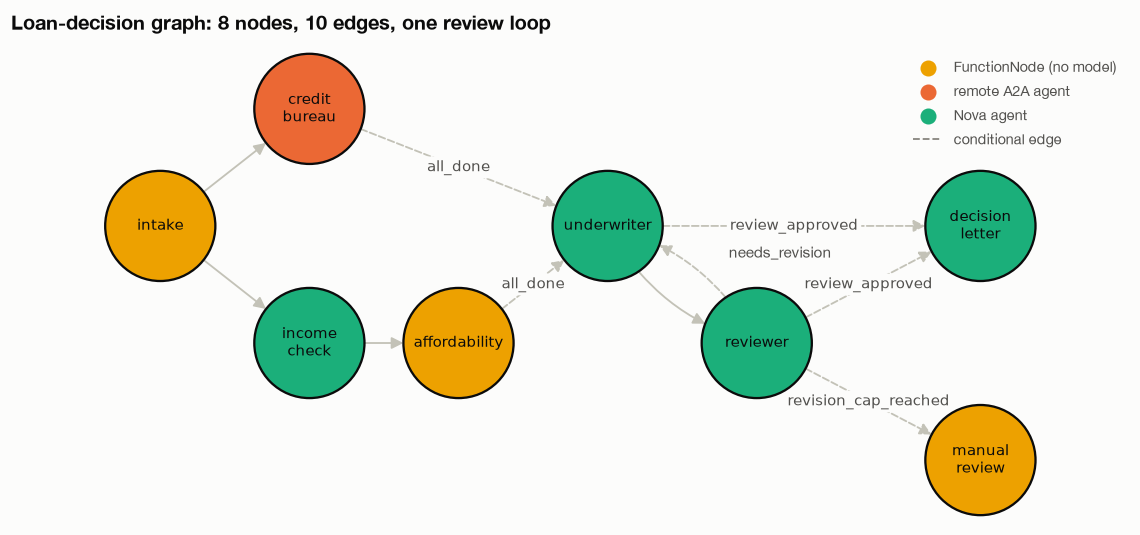

In [27]:
LOAN_NODES, LOAN_EDGES, LOAN_LABELS = viz.graph_to_topology(loan_graph, remote_types=(A2AAgent,))
LOAN_ROLE_NAMES = {"function": "FunctionNode (no model)", "remote": "remote A2A agent", "specialist": "Nova agent"}
LOAN_FLOW_POS = {node: (1.6 * col, row) for node, (col, row) in {       # flowchart layout: (column, row)
    "intake": (0, 0), "credit_bureau": (1, 0.9), "income_check": (1, -0.9), "affordability": (2, -0.9),
    "underwriter": (3, 0), "reviewer": (4, -0.9), "decision_letter": (5.5, 0), "manual_review": (5.5, -1.8)}.items()}
LOAN_LOOP_EDGE = ("reviewer", "underwriter")


def executed_edges(order: list[str]) -> list[tuple[str, str]]:
    """Edges whose source ran before the target's last visit: the path a run actually took."""
    first = {node: order.index(node) for node in order}
    last = {node: i for i, node in enumerate(order)}
    return [(a, b) for a, b in LOAN_EDGES if a in first and b in last and first[a] < last[b]]


def draw_loan_graph(ax, title: str, order: list[str] | None = None) -> None:
    """Conditional edges dashed and labelled; with `order`, only the executed path is inked."""
    viz.draw_topology(LOAN_NODES, LOAN_EDGES, pos=LOAN_FLOW_POS, node_size=5200, title=title, ax=ax,
                      edge_labels={e: name for e, name in LOAN_LABELS.items() if e != LOAN_LOOP_EDGE},
                      dashed=LOAN_LABELS.keys(), walked=executed_edges(order) if order else (),
                      visited=set(order) if order else None, role_names=LOAN_ROLE_NAMES)
    (x1, y1), (x2, y2) = LOAN_FLOW_POS["underwriter"], LOAN_FLOW_POS["reviewer"]    # label the loop on its own arc
    ax.text((x1 + x2) / 2 + 0.5, (y1 + y2) / 2 + 0.25, LOAN_LABELS[LOAN_LOOP_EDGE], fontsize=10, color=viz.INK_2,
            ha="left", va="center", bbox={"boxstyle": "round,pad=0.2", "fc": viz.SURFACE, "ec": "none"})
    handles, names = ax.get_legend_handles_labels()       # the node roles; add one entry for the dashed edges
    handles.append(Line2D([], [], color=viz.MUTED, linestyle="--", linewidth=1.2))
    ax.legend(handles, names + ["conditional edge"], loc="upper right", fontsize=9.5)


fig, ax = plt.subplots(figsize=(10.5, 5))
draw_loan_graph(ax, f"Loan-decision graph: {len(LOAN_NODES)} nodes, {len(LOAN_EDGES)} edges, one review loop")
plt.tight_layout()
plt.show()

**What to notice:**
- Orange is the remote partner, yellow is plain Python, aqua is a Nova agent. Three of the eight nodes never call a
  model.
- Dashed edges are conditional, and each label is the Python function that decides the route. Both edges into
  `underwriter` carry the same `all_done` condition: that is the explicit AND-join.
- The only cycle is `underwriter ⇄ reviewer`. Its exits are `review_approved` (to the letter) and
  `revision_cap_reached` (to a person).
- Before you run it, predict: *which route will a thin credit file take?*

### 5.4 Run it and watch the events
The live trace uses only the typed events of `graph.stream_async(...)`, which is what you would stream to an
operations UI (slide 16). If the partner's node fails on AgentCore Runtime, `decide_loan()` says so and runs the
request once more on the localhost backup (slide 12).

In [28]:
def node_output(node_result: NodeResult) -> Any:
    """Structured output if the node produced one, else its text (agents, A2A agents and FunctionNodes alike)."""
    replies = node_result.get_agent_results()
    if not replies:
        return str(node_result.result)                  # a failed node carries its exception
    return replies[-1].structured_output or text_of(replies[-1])


def trace_note(node_id: str, visit: dict) -> str:
    """One short note per node visit for the live trace."""
    output = visit["output"]
    if visit["status"] == "failed":
        return f"FAILED: {mc.short(mc.mask_account(output, ACCOUNT), 70)}"
    if isinstance(output, IncomeFacts):
        return f"{output.pay_frequency}, gross ${output.gross_pay_per_period:,.0f}, {len(output.recurring_debits)} debits"
    if isinstance(output, UnderwritingDecision):
        return f"{output.decision.upper()} (score {output.credit_score}, DTI {output.dti:.2f})"
    if isinstance(output, Review):
        verdict = "approved" if output.approved else "SENT BACK"
        return f"{verdict}: policy requires {output.required_decision} ({len(output.triggers_found)} trigger(s))"
    if node_id == "credit_bureau":
        return "remote partner; its tokens are billed to Octank"
    if node_id == "decision_letter":
        return f"{len(output.split())} words"
    return "plain Python"

In [29]:
# run the graph with a live event trace (backup bureau on failure), then the results
class LoanRun(NamedTuple):
    graph: Graph
    bureau_location: str
    result: GraphResult
    visits: list[dict]            # one record per node visit, in completion order
    correlation_id: str


async def run_graph(graph: Graph, bureau_location: str, application_id: str, max_revisions: int, *,
                    trace: bool = True) -> LoanRun:
    """Stream one loan request through a graph: print a live trace and keep one record per node visit."""
    state = loan_state(application_id, max_revisions)
    visits: list[dict] = []
    starts, result, t0 = {}, None, time.perf_counter()
    if trace:
        print(f"{application_id} · credit_bureau on {bureau_location} · correlation_id {state['correlation_id']}")
    async for event in graph.stream_async(loan_task(application_id), invocation_state=state):
        kind, now = event.get("type"), time.perf_counter() - t0
        if kind == "multiagent_node_start":
            starts[event["node_id"]] = now
            if trace:
                print(f"+{now:5.1f}s  START {event['node_id']}")
        elif kind == "multiagent_node_stop":
            node_id, node_result = event["node_id"], event["node_result"]
            earlier = [v for v in visits if v["node"] == node_id]
            # An Agent node reports its LIFETIME token total, so a revisit re-counts earlier visits: keep the delta
            lifetime_tokens = node_result.accumulated_usage.get("totalTokens", 0)
            visit = {"node": node_id, "visit": len(earlier) + 1, "start": starts.get(node_id, now), "end": now,
                     "seconds": node_result.execution_time / 1000, "status": node_result.status.value,
                     "tokens": lifetime_tokens - sum(v["tokens"] for v in earlier), "output": node_output(node_result)}
            visits.append(visit)
            if isinstance(graph.nodes[node_id].executor, A2AAgent):     # A2A returns no usage: record latency only
                LEDGER.add_remote(node_id, visit["seconds"], visit["status"])
            if trace:
                name = node_id + (f" #{visit['visit']}" if visit["visit"] > 1 else "")
                print(f"+{now:5.1f}s  DONE  {name:<16}{visit['seconds']:5.1f}s {visit['tokens']:>6,} tok   "
                      f"{trace_note(node_id, visit)}")
        elif kind == "multiagent_handoff" and trace:
            print(f"{'':8}handoff {' + '.join(event['from_node_ids'])} -> {' + '.join(event['to_node_ids'])}")
        elif kind == "multiagent_result":
            result = event["result"]
    return LoanRun(graph, bureau_location, result, visits, state["correlation_id"])


async def decide_loan(application_id: str, max_revisions: int = 2, *, trace: bool = True,
                      bureau_session: str | None = None) -> LoanRun:
    """One request = one fresh graph. If the partner's node fails on AgentCore Runtime, re-run ONCE on the backup."""
    graph, where = build_loan_graph(bureau_session=bureau_session)
    try:
        return await run_graph(graph, where, application_id, max_revisions, trace=trace)
    except Exception as err:                                        # Graph is fail-fast: the node's exception
        partner_failed = "credit_bureau" in {node.node_id for node in graph.state.failed_nodes}
        if not (partner_failed and where == "AgentCore Runtime"):
            raise                                                   # another node failed, or no backup is left
        reason = mc.mask_account(f"{type(err).__name__}: {err}", ACCOUNT)     # error URLs contain the runtime ARN
        print(f"!! credit_bureau failed on AgentCore Runtime: {mc.short(reason, 100)}\n"
              f"!! slide 12, redundancy: running {application_id} once more with the backup instance on localhost")
        graph, where = build_loan_graph(local_bureau=True)
        return await run_graph(graph, where, application_id, max_revisions, trace=trace)


with LEDGER.scope("§5 Graph"):
    run_2003 = mc.run_async(decide_loan("APP-2003", max_revisions=2, bureau_session=GRAPH_BUREAU_SESSION))

APP-2003 · credit_bureau on AgentCore Runtime · correlation_id APP-2003-1c6503
+  0.0s  START intake
+  0.0s  DONE  intake            0.0s      0 tok   plain Python
        handoff intake -> credit_bureau + income_check
+  0.0s  START credit_bureau
+  0.0s  START income_check


+  1.9s  DONE  income_check      1.9s  2,452 tok   bi-weekly, gross $2,000, 2 debits


+  8.8s  DONE  credit_bureau     8.8s      0 tok   remote partner; its tokens are billed to Octank
        handoff credit_bureau + income_check -> affordability
+  8.8s  START affordability
+  8.8s  DONE  affordability     0.0s      0 tok   plain Python
        handoff affordability -> underwriter
+  8.8s  START underwriter


+ 11.7s  DONE  underwriter       2.8s  2,152 tok   APPROVE (score 671, DTI 0.33)
        handoff underwriter -> reviewer
+ 11.7s  START reviewer


+ 14.7s  DONE  reviewer          3.1s  2,016 tok   SENT BACK: policy requires refer (2 trigger(s))
        handoff reviewer -> underwriter
+ 14.7s  START underwriter


+ 17.0s  DONE  underwriter #2    2.2s  2,101 tok   REFER (score 671, DTI 0.33)
        handoff underwriter -> reviewer
+ 17.0s  START reviewer


+ 20.6s  DONE  reviewer #2       3.7s  2,239 tok   approved: policy requires refer (2 trigger(s))
        handoff reviewer -> decision_letter
+ 20.6s  START decision_letter


+ 22.1s  DONE  decision_letter   1.5s  2,504 tok   27 words


In [30]:
# run the graph with a live event trace (backup bureau on failure), then the results
result_2003, visits_2003 = run_2003.result, run_2003.visits
path_2003 = [node.node_id for node in result_2003.execution_order]
rounds_2003 = path_2003.count("underwriter")
ledger_2003 = LEDGER.df("§5 Graph")
ledger_2003 = ledger_2003[ledger_2003["correlation_id"] == run_2003.correlation_id]
print(f"status            : {result_2003.status.value}   (credit_bureau on {run_2003.bureau_location})")
print(f"execution_order   : {' -> '.join(path_2003)}")
print(f"review loop fired : {f'yes, {rounds_2003 - 1} revision(s)' if rounds_2003 > 1 else 'no'}")
print(f"execution_time    : {result_2003.execution_time / 1000:.1f} s for {len(path_2003)} node visits (limit 12)")
print(f"tokens            : GraphResult.accumulated_usage {result_2003.accumulated_usage['totalTokens']:,}  ·  "
      f"per-visit sum {sum(v['tokens'] for v in visits_2003):,}  ·  "
      f"ledger (per invocation) {int(ledger_2003[['input_tokens', 'output_tokens']].sum().sum()):,}")

# GraphResult keeps only the LATEST visit per node, so the round-by-round history comes from the streamed events
maker_2003 = [v["output"] for v in visits_2003 if v["node"] == "underwriter"]
checker_2003 = [v["output"] for v in visits_2003 if v["node"] == "reviewer"]
display(pd.DataFrame([
    {"round": i, "maker decides": d.decision, "score": d.credit_score, "thin_file": d.thin_file, "DTI": d.dti,
     "checker finds": mc.short("; ".join(r.triggers_found), 60) or "no triggers",
     "policy requires": r.required_decision, "verdict": "approved" if r.approved else "sent back"}
    for i, (d, r) in enumerate(zip(maker_2003, checker_2003), start=1)]).set_index("round"))

final_2003 = result_2003.results["underwriter"].result.structured_output
print(f"final rationale   : {final_2003.rationale}")
print(f"final conditions  : {final_2003.conditions}")

applicant_2003 = bank.get_customer_profile(bank.get_application("APP-2003")["customer_id"])
final_text_2003 = node_output(result_2003.results[path_2003[-1]])
if path_2003[-1] == "decision_letter":
    viz.chat(f"AnyCompany Bank -> {applicant_2003['name']} · channel: {applicant_2003['preferred_channel']} · "
             f"{len(final_text_2003.split())} words", final_text_2003, role="agent")
    # A prompt is not a contract (slide 24): code checks the customer-facing text before anything is sent
    LETTER_OUTCOME_PATTERNS = {"refer": r"loan officer", "approve": r"(?<!not )approved",
                               "decline": r"not approved|unable"}
    letter_checks_2003 = {
        "≤ 120 words": len(final_text_2003.split()) <= 120,
        "no internal terms": not re.search(r"credit score|\bDTI\b|debt-to-income|polic|underwrit|reviewer|\b671\b",
                                           final_text_2003, re.I),
        f"says the outcome ({final_2003.decision})": bool(re.search(LETTER_OUTCOME_PATTERNS[final_2003.decision],
                                                                   final_text_2003, re.I)),
        "signed 'AnyCompany Bank Lending'": "AnyCompany Bank Lending" in final_text_2003,
    }
    print("letter checks     : " + "  ·  ".join(f"{'✓' if ok else '✗'} {check}"
                                                for check, ok in letter_checks_2003.items()))
else:
    viz.chat("manual_review (escalation)", final_text_2003, role="system")

status            : completed   (credit_bureau on AgentCore Runtime)
execution_order   : intake -> income_check -> credit_bureau -> affordability -> underwriter -> reviewer -> underwriter -> reviewer -> decision_letter
review loop fired : yes, 1 revision(s)
execution_time    : 22.1 s for 9 node visits (limit 12)
tokens            : GraphResult.accumulated_usage 17,632  ·  per-visit sum 13,464  ·  ledger (per invocation) 13,464


,maker decides,score,thin_file,DTI,checker finds,policy requires,verdict
round,,,,,,,
1,approve,671,True,0.33,credit score within 20 points of product minim...,refer,sent back
2,refer,671,True,0.33,credit score within 20 points of minimum; thin...,refer,approved


final rationale   : Credit score is 671 and DTI is 0.33. Decision referred due to reviewer triggers: credit score within 20 points of minimum and thin credit file.
final conditions  : ['loan officer review']


letter checks     : ✓ ≤ 120 words  ·  ✓ no internal terms  ·  ✓ says the outcome (refer)  ·  ✓ signed 'AnyCompany Bank Lending'


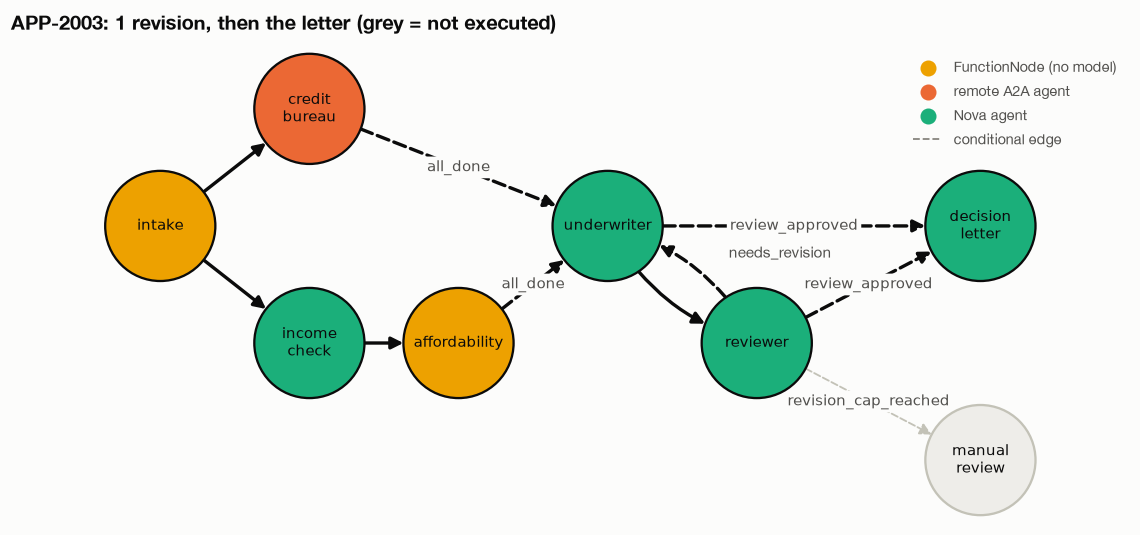

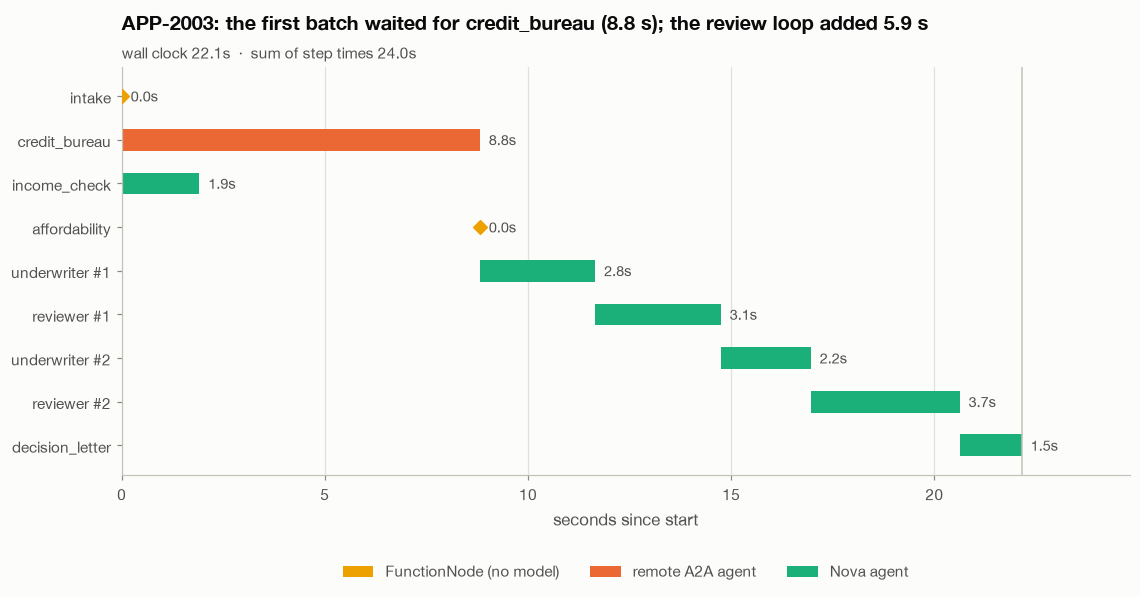

In [31]:
last_step_2003 = "the letter" if path_2003[-1] == "decision_letter" else "a loan officer"
revisions_2003 = f"{rounds_2003 - 1} revision{'' if rounds_2003 == 2 else 's'}"
fig, ax = plt.subplots(figsize=(10.5, 5))
draw_loan_graph(ax, f"APP-2003: {revisions_2003}, then {last_step_2003} (grey = not executed)", order=path_2003)
plt.tight_layout()
plt.show()

# Timeline of every node visit: parallel batch, AND-join wait and the sequential review loop
labels_2003 = [v["node"] + (f" #{v['visit']}" if path_2003.count(v["node"]) > 1 else "") for v in visits_2003]
batch_2003 = {v["node"]: v["seconds"] for v in visits_2003 if v["node"] in ("credit_bureau", "income_check")}
slowest_2003 = max(batch_2003, key=batch_2003.get)            # the next batch starts when this one finishes
loop_s_2003 = sum(v["seconds"] for v in visits_2003 if v["visit"] > 1)
fig, ax = plt.subplots(figsize=(10.5, 0.42 * len(visits_2003) + 1.9))
viz.gantt([{"name": label, "start": v["start"], "end": v["end"], "group": LOAN_ROLE_NAMES[LOAN_NODES[v["node"]]]}
           for label, v in zip(labels_2003, visits_2003)], ax=ax,
          title=f"APP-2003: the first batch waited for {slowest_2003} ({batch_2003[slowest_2003]:.1f} s); "
                f"the review loop added {loop_s_2003:.1f} s",
          group_colors={LOAN_ROLE_NAMES[r]: viz.ROLE_COLORS[r] for r in LOAN_ROLE_NAMES})
plt.tight_layout()
plt.show()

**What to notice:**
- `credit_bureau` and `income_check` start in one batch. In the Gantt, `affordability` needs only `income_check`
  yet waits for the slow partner: the batch barrier, not the AND-join. FunctionNodes take about 0 s and 0 tokens.
- **The route.** In our test runs the maker approves on the hard limits, the checker finds two manual-review
  triggers (thin file, score within 20 points of the minimum) and sends it back, and round 2 returns `REFER`.
  Routing reads typed fields (`review.approved`), never prose. Each round adds two sequential bars.
- **The letter checks are code, not a prompt** (slide 24): in some test runs only the `no internal terms` check
  caught a letter that mentioned the credit score.
- The partner node reports 0 tokens, and `GraphResult.accumulated_usage` over-counts revisited nodes (Strands
  1.57.1): bill from the per-invocation ledger.

---
## §8 — AgentCore Memory, part 2: two days later
While we built the Graph, the strategies extracted Sofia's Day-1 turns. The next cell waits until her email
preference and remodel plan are **listed** and **found by the agents' own search**.

In [32]:
if MEMORY_READY:
    day1_records = wait_for_records(CUSTOMER_PATH, learned({"email"}, {"kitchen", "remodel"}), label="Day 1")
    display(ltm_table(day1_records))

  72s  CustomerFacts: 4  ·  CustomerPreferences: 3  ·  SessionSummaries: 1   -> ready

,strategy,namespace,record
0,CustomerFacts,/customers/cust-1001/facts/,The user is planning a kitchen remodel startin...
1,CustomerFacts,/customers/cust-1001/facts/,The user prefers to be contacted by email only...
2,CustomerFacts,/customers/cust-1001/facts/,The user is looking at a home improvement loan...
3,SessionSummaries,/customers/cust-1001/sessions/<day 1>/,"[Loan Inquiry] The user is seeking a $25,000 h..."
4,CustomerPreferences,/customers/cust-1001/preferences/,"Follow-ups should be sent by email only, not b..."
5,CustomerPreferences,/customers/cust-1001/preferences/,Kitchen remodel starts in November
6,CustomerPreferences,/customers/cust-1001/preferences/,"Seeking a home improvement loan of about $25,0..."
7,CustomerFacts,/customers/cust-1001/facts/,The user has a loan application APP-2001 in pr...


### 8.6 Days 3 and 7: a different specialist, the same customer memory

**Day 3, a new session, and a card problem.** Sofia doesn't mention email, her remodel or the loan. "My project"
only makes sense if the bank remembers her.

In [33]:
if MEMORY_READY:
    run_day("Day 3")

**What to notice (Day 3):**
* **Cross-agent sharing:** the cards specialist has never talked to Sofia. Its STM for this session holds only
  today's orchestrator turn, so the remodel and the email preference can only come from **long-term memory**.
* Look for "my project" resolved to the kitchen remodel and email as the follow-up channel. The check below
  tests both deterministically.
* If the orchestrator's line shows `LTM: 0` while the specialist's shows records, the search index was still
  catching up (search can lag the record list by up to a minute), and the specialist searched a few seconds later.

**Day 7:** "Any update on my application?" Which application? Its *status* is state, so the lending specialist reads
it from the system of record through a tool (slide 34). Watch the memory lines: LTM may also hold a Day-1 snapshot
of the application, a copy of state that goes stale (the classic bug in slide 28's notes).

In [34]:
if MEMORY_READY:
    run_day("Day 7")

**Did the team remember without Sofia repeating herself?** Slide 39's benefits (continuity, personalized
service, coordination without manual handoffs), checked with deterministic string matching on the final replies,
not a model judgement. The `comes from` column keeps memory and tools apart. A `–` means the reply did not use that
fact; the memory lines above show whether it was loaded (retrieval makes context available, the prompt decides):

In [35]:
REMEMBERED = {"email follow-up": ["email"], "kitchen remodel in November": ["kitchen", "remodel", "november"],
              "application APP-2001": ["app-2001"]}
COMES_FROM = {"email follow-up": "long-term memory (Day 1)", "kitchen remodel in November": "long-term memory (Day 1)",
              "application APP-2001": "status: system of record (tool); id: tool or memory"}
EXPECTED = {"Day 3": ["email follow-up", "kitchen remodel in November"], "Day 7": list(REMEMBERED)}


def remembered_in(text: str, day: str, fact: str) -> str:
    if fact not in EXPECTED[day]:
        return "n/a"
    return "✓" if any(word in text.lower() for word in REMEMBERED[fact]) else "–"


if MEMORY_READY:
    memory_check = pd.DataFrame({"comes from": COMES_FROM} | {
        day: {fact: remembered_in(ANSWERS.get(day, ""), day, fact) for fact in REMEMBERED} for day in EXPECTED})
    memory_check.loc["Sofia repeated any of it?"] = [""] + [
        "yes" if any(remembered_in(SOFIA[day], day, fact) == "✓" for fact in EXPECTED[day]) else "no" for day in EXPECTED]
    display(memory_check)

,comes from,Day 3,Day 7
email follow-up,long-term memory (Day 1),✓,✓
kitchen remodel in November,long-term memory (Day 1),✓,✓
application APP-2001,status: system of record (tool); id: tool or m...,n/a,✓
Sofia repeated any of it?,,no,no


## §9 — Wrap-up: what did we see, and what did it cost?
The first cell counts what AgentCore Memory billed for Sofia's week, while the memory still exists. The second starts
the **§10 cleanup in the background**: the partner's runtime, IAM role, S3 bucket and log groups, and the memory, all
named with this `RUN_ID`. Both are collapsed; the rest reads data already in this kernel.

In [36]:
# AgentCore Memory bills events, stored records and retrieved records, not tokens, so the Nova ledger misses it.
# Count them now, before the §10 cleanup deletes the memory; the cost section prints the bill (prices as in s08 8.11).
d20_memory_bill = None
if MEMORY_READY:
    try:
        d20_events = sum(len(session_manager.create_memory_session(actor_id=d20_actor, session_id=d20_session)
                             .list_events(max_results=100, include_payload=False))
                         for d20_session in SESSIONS.values() for d20_actor in TEAM)
        d20_stored = len(ltm_frame())
        d20_memory_bill = {"events": d20_events, "stored": d20_stored, "retrieved": MEMORY_RETRIEVALS["records"],
                           "searches": MEMORY_RETRIEVALS["calls"],
                           "usd": (d20_events * 0.25 + d20_stored * 0.75 + MEMORY_RETRIEVALS["records"] * 0.50) / 1000,
                           "nova_usd": LEDGER.df("§8 shared memory").get("cost_usd", pd.Series(dtype=float)).sum()}
    except Exception as d20_err:                                 # keep "Run All" going: the cleanup comes next
        print(f"AgentCore Memory bill not counted: {type(d20_err).__name__}")

In [37]:
# start the §10 cleanup in a background thread
import shutil
import sys
import threading
from botocore.exceptions import ClientError

CLEANUP = {"done": [], "problems": []}


def _cleanup_step(label, fn):
    """Run one cleanup step; record what it deleted or why it failed, never raise."""
    try:
        out = fn()
        CLEANUP["done"].extend(out if isinstance(out, list) else [label])
    except Exception as e:  # noqa: BLE001 - a failed step must not stop the others
        CLEANUP["problems"].append(f"{label}: {type(e).__name__}: {e}")


def _delete_memory() -> list[str]:
    ctl = SESSION.client("bedrock-agentcore-control")
    try:
        ctl.delete_memory(memoryId=MEMORY_ID)
    except ctl.exceptions.ResourceNotFoundException:
        return [f"AgentCore Memory {MEMORY_ID} (already gone)"]
    for _ in range(36):                                          # deletion is asynchronous (~1-3 min)
        try:
            if ctl.get_memory(memoryId=MEMORY_ID)["memory"]["status"] != "DELETING":
                break
        except ctl.exceptions.ResourceNotFoundException:
            break
        time.sleep(5)
    return [f"AgentCore Memory {MEMORY_ID}"]


def _stop_local() -> list[str]:
    stopped = []
    for name, obj in list(globals().items()):                    # every local A2A server started in this kernel
        if isinstance(obj, mc.A2AServerThread) and obj.thread.is_alive():
            obj.stop(); stopped.append(f"local A2A server :{obj.port} ({name})")
    srv = _local_bureau.get("server")
    if srv is not None and srv.thread.is_alive():
        srv.stop(); stopped.append("local bureau backup")
    wf_module = sys.modules.get("strands_tools.workflow")       # only if §4.8 imported it (importing creates dirs)
    try:                                                         # §4's workflow tool keeps a file watcher thread
        WorkflowManager = getattr(wf_module, "WorkflowManager", None)
        if WorkflowManager is not None and WorkflowManager._instance is not None:
            WorkflowManager._instance.cleanup(); stopped.append("workflow tool file watcher")
    except Exception:  # noqa: BLE001
        pass
    folder = NOTEBOOK_DIR / ".workflows"
    if folder.exists():
        shutil.rmtree(folder, ignore_errors=True); stopped.append("local folder .workflows/")
    return stopped


def _cleanup_all():
    if globals().get("bureau_job") is not None:                  # waits for an in-flight deployment first
        _cleanup_step("AgentCore Runtime + IAM role + S3 bucket + logs", bureau_job.teardown)
    if globals().get("MEMORY_ID"):
        _cleanup_step(f"AgentCore Memory {MEMORY_ID}", _delete_memory)
    _cleanup_step("local servers and folders", _stop_local)


if globals().get("cleanup_thread") is None or not cleanup_thread.is_alive():
    cleanup_thread = threading.Thread(target=_cleanup_all, name="m01-cleanup", daemon=True)
    cleanup_thread.start()
print(f"Cleanup of RUN_ID {RUN_ID} started in the background (1–3 min). §10 below shows the result.")

Cleanup of RUN_ID 20260928-091109-55e9 started in the background (1–3 min). §10 below shows the result.


### Discussion prompts

**Think about it:** Sofia asks the bank to forget her kitchen remodel (slide 39). List every place it lives in this
design, and the API or setting that removes each one. (The course's full notebook tries it in §8.10; it is not part of this repository.)

<details><summary>More prompts (labs, Q&A)</summary>

1. We extracted customer memories **only from the orchestrator's stream**. What would go wrong if every specialist's
   events also carried `{customerid}`? When might you want that anyway?
2. Which agent may read `/customers/{customerid}/facts/`, and which only `/preferences/`? How would
   you enforce it with IAM condition keys (`bedrock-agentcore:namespace`, `namespaceVariable/<key>`)?
3. LTM appeared minutes after the conversation. Where in a real customer journey does that asynchronous gap hurt?
   What would you keep in STM or in `invocation_state` instead?
4. The standing query doubles the searches on every turn. How would you cache core context per session, and what
   should invalidate that cache?
5. The episodic strategy writes per-agent reflections. What would the cards specialist learn after a hundred
   duplicate-charge disputes? Who should review those reflections before agents rely on them?

</details>

### What did each pattern cost? (slide 38)
A ledger hook on every agent recorded tokens, dollars and latency per invocation (*track cost and latency per
agent*). The chart is **Amazon Nova only**; the first line below adds AgentCore Memory, which bills events, stored
records and retrievals instead of tokens (the partner's Runtime seconds are not counted). The table divides by the
work done (one question, one loan application), so the patterns compare like for like.

In [38]:
# the bill the Nova chart leaves out: AgentCore Memory, counted at the top of §9 before the cleanup
if globals().get("d20_memory_bill"):
    print(f"AgentCore Memory (not in the chart): {d20_memory_bill['events']} events ($0.25 per 1k) + "
          f"{d20_memory_bill['stored']} records stored ($0.75 per 1k per month) + {d20_memory_bill['retrieved']} "
          f"records retrieved by {d20_memory_bill['searches']} searches ($0.50 per 1k) = ${d20_memory_bill['usd']:.4f}"
          f"\nAmazon Nova for the same §8 agents: ${d20_memory_bill['nova_usd']:.4f}")
else:
    print("AgentCore Memory: not counted in this run (§8 did not run, or the count failed at the top of §9).")

AgentCore Memory (not in the chart): 12 events ($0.25 per 1k) + 8 records stored ($0.75 per 1k per month) + 63 records retrieved by 26 searches ($0.50 per 1k) = $0.0405
Amazon Nova for the same §8 agents: $0.0094


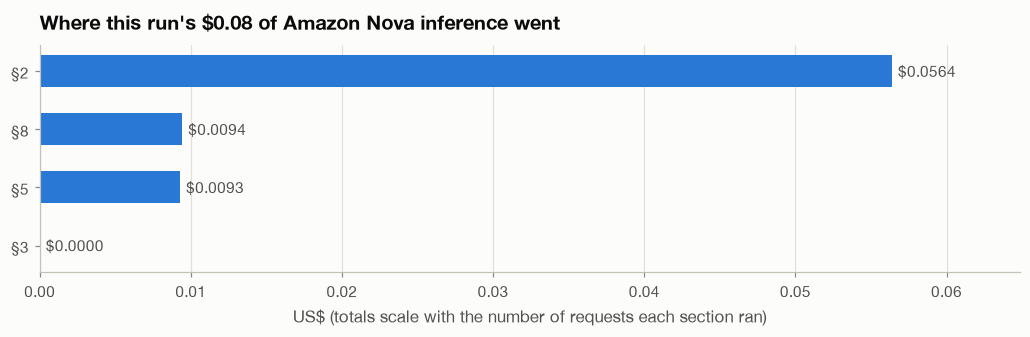

172,584 input + 7,076 output tokens · 50 agent invocations · 106 model calls


In [39]:
ledger = LEDGER.df()
if ledger.empty:
    print("The ledger is empty — run a few sections first.")
else:
    ledger["section"] = ledger["scope"].str.extract(r"^(§\d+)", expand=False).fillna("other")
    by_section = (ledger.groupby("section")[["input_tokens", "output_tokens", "cost_usd", "model_calls"]].sum()
                  .sort_values("cost_usd", ascending=False))
    total = by_section["cost_usd"].sum()
    fig, ax = plt.subplots(figsize=(9.5, 0.45 * len(by_section) + 1.4))
    viz.hbar(list(by_section.index), list(by_section["cost_usd"]), fmt="${:.4f}", ax=ax,
             title=f"Where this run's \\${total:.2f} of Amazon Nova inference went")
    ax.set_xlabel("US$ (totals scale with the number of requests each section ran)")
    plt.tight_layout(); plt.show()
    print(f"{ledger['input_tokens'].sum():,} input + {ledger['output_tokens'].sum():,} output tokens · "
          f"{len(ledger)} agent invocations · {int(ledger['model_calls'].sum())} model calls")

In [40]:
# cost per unit of work from the ledger (lists §4 and §6 too; rows not run are dropped)
def unit_cost(scope_prefix: str, units: int) -> float | None:
    """US$ per unit of work for every ledger row whose scope starts with scope_prefix (None if not run)."""
    rows = ledger[ledger["scope"].str.startswith(scope_prefix)] if not ledger.empty else ledger
    return None if rows.empty or not units else rows["cost_usd"].sum() / units


PER_UNIT = [  # (pattern, AnyCompany job, unit of work, ledger scope prefix, units run in that scope)
    ("single agent", "answer a customer question", "question", "§2 single-agent baseline", len(bank.EVAL_QUESTIONS)),
    ("agent as tool", "answer a customer question", "question", "§2 eval", len(bank.EVAL_QUESTIONS)),
    ("workflow", "process a loan's documents", "application", "§4 Workflow", 1),
    ("graph", "decide a loan", "application", "§5 Graph", 1),
    ("swarm", "investigate a fraud alert", "alert", "§6 Swarm", 1),
]
per_unit = pd.DataFrame([{"pattern": p, "AnyCompany job": job, "unit": u, "US$ per unit": unit_cost(scope, n)}
                         for p, job, u, scope, n in PER_UNIT]).dropna()
if per_unit.empty:
    print("Run §2 and §4–§6 to fill this table.")
else:
    display(per_unit.style.format({"US$ per unit": "${:.4f}"}).hide(axis="index"))
    base = per_unit.set_index("pattern")["US$ per unit"].get("single agent")
    if base:
        print(f"Relative to one single-agent answer (${base:.4f}):")
        for p, v in per_unit.set_index("pattern")["US$ per unit"].items():
            if p != "single agent":
                print(f"  {p:<14} {v / base:4.1f}×")

pattern,AnyCompany job,unit,US$ per unit
single agent,answer a customer question,question,$0.0024
agent as tool,answer a customer question,question,$0.0031
graph,decide a loan,application,$0.0093


Relative to one single-agent answer ($0.0024):
  agent as tool   1.3×
  graph           3.9×


### Call to action (slide 45)
Sketch how you would split an agent you have built, and what memory each part needs.

## §10 — Cleanup (don't skip this)
The cleanup started at the top of §9. It deletes **only what this notebook created**, all named with this run's
`RUN_ID`: the AgentCore Runtime (partner agent) with its IAM role, S3 code bucket and log groups; the AgentCore Memory;
and the local A2A servers and scratch folders. Nothing else in the account is touched. If the kernel died, run
`python teardown_m01.py --run-id <RUN_ID>` (or `--last`) from a terminal instead.

In [41]:
# §10: join the cleanup thread, then verify every resource of this RUN_ID by id
if globals().get("cleanup_thread") is None:                     # §9 was skipped: run the cleanup now
    cleanup_thread = threading.Thread(target=_cleanup_all, daemon=True); cleanup_thread.start()
cleanup_thread.join(timeout=360)
print("Deleted / stopped:")
for item in CLEANUP["done"]:
    print("  ✓", mc.mask_account(item, ACCOUNT))
if cleanup_thread.is_alive():
    print("  … still running in the background (re-run this cell in a minute)")
for p in CLEANUP["problems"]:
    print("  ✗", mc.mask_account(p, ACCOUNT))
if CLEANUP["problems"]:
    print(f"Finish from a terminal:  python teardown_m01.py --run-id {RUN_ID}")

Deleted / stopped:
  ✓ runtime mladas_m01_bureau_2026092809110955e9-v18Gxr7JOm (deleting)
  ✓ log group /aws/bedrock-agentcore/runtimes/mladas_m01_bureau_2026092809110955e9-v18Gxr7JOm-DEFAULT
  ✓ IAM role mladas-m01-bureau-2026092809110955e9
  ✓ S3 bucket mladas-************-2026092809110955e9
  ✓ AgentCore Memory MLADAS_M01_20260928_091109_55e9-dwRiFG71WK


In [42]:
# §10: join the cleanup thread, then verify every resource of this RUN_ID by id
# Verify by asking for this run's resources directly (no list scans, so no pagination blind spots)
def _gone(check) -> bool:
    try:
        check()
        return False
    except ClientError as e:
        return e.response["Error"]["Code"] in ("ResourceNotFoundException", "NoSuchEntity", "404", "NoSuchBucket")


ctl = SESSION.client("bedrock-agentcore-control")
checks = {}
if globals().get("bureau_job") is not None:
    checks["AgentCore Runtime"] = (not bureau_job.runtime_id) or _gone(
        lambda: ctl.get_agent_runtime(agentRuntimeId=bureau_job.runtime_id)) or \
        ctl.get_agent_runtime(agentRuntimeId=bureau_job.runtime_id)["status"] == "DELETING"
    checks["IAM role"] = _gone(lambda: SESSION.client("iam").get_role(RoleName=bureau_job.role_name))
    checks["S3 code bucket"] = _gone(lambda: SESSION.client("s3").head_bucket(Bucket=bureau_job.bucket))
    checks["runtime log groups"] = not SESSION.client("logs").describe_log_groups(
        logGroupNamePrefix=f"/aws/bedrock-agentcore/runtimes/{bureau_job.name}")["logGroups"]
if globals().get("MEMORY_ID"):
    checks["AgentCore Memory"] = _gone(lambda: ctl.get_memory(memoryId=MEMORY_ID)) or \
        ctl.get_memory(memoryId=MEMORY_ID)["memory"]["status"] == "DELETING"
for what, ok in checks.items():
    print(f"{what:<20} {'gone ✓' if ok else 'STILL THERE ✗ -> python teardown_m01.py --run-id ' + RUN_ID}")

AgentCore Runtime    gone ✓
IAM role             gone ✓
S3 code bucket       gone ✓
runtime log groups   gone ✓
AgentCore Memory     gone ✓
